<div align="center">

# Notebook 10 — Pantagruel (speech-large-14K) + WavLM Base-Plus + résidu vocodeur (Vocos)

# Classification multi-classes FOCH

**Fusion tri-branche — deux encodeurs de parole gelés + résidu vocodeur log-mel**

![Python](https://img.shields.io/badge/Python-3.12-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.11-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)
![Vocos](https://img.shields.io/badge/Vocos-r%C3%A9sidu%20vocodeur-8A2BE2?style=flat-square)

</div>


## Synthèse de l'architecture tri-branche

Ce notebook conserve intégralement le protocole d'évaluation du template (`StratifiedKFold` à 5 plis, déduplication patient, augmentation injectée dans le seul train, `FocalLoss` pondérée par pli) et n'en change que la **partie représentation**. Trois branches, toutes activables indépendamment via le preset `BACKBONE` (Cellule 1) :

| Branche | Modèle / source | Entraînable ? | Sortie |
|---|---|---|---|
| **A — WavLM Base-Plus** | `microsoft/wavlm-base-plus`, répertoire local | **gelée** | moyenne temporelle du `last_hidden_state` → 768-d |
| **B — Pantagruel `speech-large-14K`** | dépôt local `speech-large-14K` (`trust_remote_code=True`) | **gelée** | moyenne temporelle du `last_hidden_state` → dimension **résolue à l'exécution** |
| **C — Résidu vocodeur (Vocos)** | `charactr/vocos-mel-24khz`, répertoire local, inférence CPU | **gelé** — seule la projection est apprise | 6 statistiques log-mel → `RESIDUAL_PROJ_DIM`-d après `Linear → ReLU` |

**1 — Pourquoi Pantagruel plutôt qu'un backbone AudioSet.** Le corpus FOCH est exclusivement **francophone**. Pantagruel `speech-large-14K` est un encodeur data2vec-2.0 pré-entraîné sur ~14 000 h de **parole française**, là où AST/CNN14 sont entraînés sur des événements sonores généralistes (AudioSet) et WavLM sur de l'anglais (LibriLight/GigaSpeech/VoxPopuli). L'appariement langue ↔ locuteurs est le seul changement de domaine gratuit disponible ici : il ne coûte aucun paramètre entraînable supplémentaire, les deux encodeurs restant gelés.

**2 — Pourquoi conserver WavLM à côté.** Les deux encodeurs ne sont pas redondants : WavLM Base-Plus est entraîné avec un objectif de **débruitage/mélange de locuteurs**, ce qui le rend sensible au détail acoustique microscopique (apériodicité court terme, bruit additif), tandis que Pantagruel encode une représentation phonétique/prosodique française plus macroscopique. On concatène les deux plutôt que d'arbitrer *a priori* ; les presets solo (`wavlm_bp_solo`, `pantagruel_solo`) permettent de mesurer l'apport réel de chacun.

> ⚠️ **Base-Plus ≠ Base.** `wavlm-base-plus` est un **checkpoint distinct** (pré-entraînement 94 kh contre 960 h), et non une variante de configuration de `wavlm-base` : les deux partagent la même architecture 12 couches / 768-d mais pas les mêmes poids. Les trois répertoires (`wavlm-base`, `wavlm-base-plus`, `wavlm-large`) coexistent dans `WAVLM_DIRS` ; seul `base_plus` est référencé par les presets de ce notebook.

**3 — Troisième branche : résidu vocodeur en domaine log-mel.** Un vocodeur neuronal pré-entraîné et **gelé** (Vocos, `charactr/vocos-mel-24khz`) resynthétise chaque enregistrement à partir de son propre spectrogramme log-mel ; l'écart entre le mel original et le mel de la resynthèse — calculé en domaine **log-mel plutôt qu'en forme d'onde brute**, pour rester indépendant de la phase (cf. Cellule 1 et Cellule 4 pour la justification empirique) — est résumé par 6 statistiques (énergie, profil bande grave/médiane/aiguë, platitude spectrale, entropie temporelle) et projeté vers `RESIDUAL_PROJ_DIM`-d. Remplace l'ancienne branche bioacoustique Praat (CPPS/jitter/shimmer/HNR) de ce notebook — cf. Cellule 6 pour la justification détaillée et le journal des modifications (fin de notebook) pour le raisonnement complet du changement.

**4 — Portée du fine-tuning : la tête uniquement.** Les deux encodeurs profonds sont **intégralement gelés**, sans exception ni dégel tardif. Seuls la tête de fusion et la projection du résidu vocodeur reçoivent un gradient. Ce notebook ne contient donc **aucune** logique de dégel progressif : elle a été retirée, et non désactivée, pour que le code décrive exactement ce qu'il fait.

> Les justifications détaillées accompagnent chaque section (Cellules 1, 4, 4b, 6, 6b, 7).


## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection des branches**. Le notebook met en œuvre un **classifieur tri-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**
<div align="center">

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Paralysie récurrentielle — pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Lésion de la muqueuse bénigne — support intermédiaire |
| `fuite glottique` | FOCH | Support le plus faible — classe minoritaire critique |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

</div>

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable des branches (`BACKBONE`)

Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding — la dimension de fusion est toujours la **somme** des dimensions des branches actives.

<div align="center">

| Preset | WavLM Base-Plus | Pantagruel | Résidu vocodeur | Fusion |
|---|---|---|---|---|
| `pantagruel_wavlm_bp_residual` *(défaut)* | ✅ 768-d | ✅ *(dim. résolue à l'exécution)* | ✅ `RESIDUAL_PROJ_DIM` | somme des trois |
| `pantagruel_wavlm_bp` | ✅ 768-d | ✅ | — | somme des deux |
| `pantagruel_solo` | — | ✅ | — | dim. Pantagruel |
| `wavlm_bp_solo` | ✅ 768-d | — | — | 768-d |
| `residual_solo` | — | — | ✅ | `RESIDUAL_PROJ_DIM` |
| `pantagruel_residual` / `wavlm_bp_residual` | selon | selon | ✅ | somme |

</div>

Les trois presets solo servent d'**ablations** : ils quantifient l'apport marginal de chaque branche dans le preset complet. `residual_solo` en particulier fournit la **référence résidu vocodeur seul** (les 6 statistiques log-mel seules) à laquelle comparer les encodeurs profonds.

> 🔌 **Chargement strictement local.** Cette machine n'a pas accès à `huggingface.co`. `HF_HUB_OFFLINE` et `TRANSFORMERS_OFFLINE` sont positionnés **avant** l'import de `transformers`, et tous les modèles sont chargés depuis des répertoires locaux avec `local_files_only=True`. Pantagruel exige en plus `trust_remote_code=True` : son code de modélisation (`modeling_pantagruel_uni.py`, `configuration_pantagruel_uni.py`, `utils_pantagruel_uni.py`) est **présent dans le dépôt local**, il n'est donc jamais téléchargé. Vocos (branche résidu) suit la même discipline — checkpoint local récupéré une fois par `git clone` + `git lfs pull` (`hf_hub_download` bloque indéfiniment sur le poids LFS sur ce réseau).

> 📦 **Dépendance `timm`.** `modeling_pantagruel_uni.py` importe `DropPath` et `Mlp` depuis `timm.models.vision_transformer`. Sans `timm` installé, `AutoModel.from_pretrained(...)` échoue à l'import du module distant (`ImportError: This modeling file requires ... timm`) — et non au chargement des poids. Le paquet est requis dans l'environnement `.aug`.

### Dimension d'embedding de Pantagruel — résolue, jamais supposée

⚠️ **Piège de configuration.** Le `config.json` de Pantagruel expose **deux** attributs de dimension contradictoires :

- `hidden_size = 768` — valeur héritée par défaut de `PretrainedConfig`, **jamais utilisée** par le graphe du modèle ;
- `embed_dim = 1024` — dimension réellement employée par toutes les couches (`modeling_pantagruel_uni.py` construit chaque bloc à partir de `config.embed_dim`).

Lire `config.hidden_size`, réflexe habituel avec les modèles HuggingFace, donnerait ici une dimension de fusion **fausse de 256**. La Cellule 1 résout donc la dimension via `_resolve_pantagruel_dim()` (priorité à `embed_dim`) et **signale explicitement** la divergence ; la Cellule 6 la **revérifie sur une passe avant réelle** et lève une assertion en cas d'écart. Aucune dimension Pantagruel n'est écrite en dur dans ce notebook.

### Branche résidu vocodeur

`RESIDUAL_FEATURES` est une **liste fixe** de 6 statistiques dérivées du résidu log-mel Vocos (Cellule 4) : énergie globale, moyenne `|résidu|` par tiers de bandes mel (grave/médian/aigu), platitude spectrale, entropie temporelle. Contrairement à l'ancien registre `_BIO_EXTRACTORS` (descripteurs Praat indépendants), ces 6 valeurs dérivent toutes du même résidu partagé — pas de registre extensible ici, volontairement, pour ne pas ajouter d'indirection sans bénéfice. Elles sont projetées par un `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU`. Sans cette projection, 6 valeurs brutes concaténées à ~1800 dimensions profondes seraient noyées : le dropout d'entrée les annulerait statistiquement et la tête les ignorerait.

### Budget mémoire

Les deux encodeurs étant gelés et exécutés sous `torch.no_grad()`, **aucune activation intermédiaire n'est conservée** pour la rétropropagation : le coût VRAM est celui d'une inférence, pas d'un entraînement, malgré ~407 M paramètres cumulés (94 M WavLM-BP + 313 M Pantagruel). Seuls la tête et la projection du résidu vocodeur (~250 k paramètres) rétropropagent ; Vocos lui-même tourne en **CPU**, hors du budget VRAM. La **sonde VRAM (Cellule 6b)** mesure le coût réel par échantillon sur cette machine (**RTX PRO 2000 portable, 8 Go**) et propose un `BATCH_SIZE` ; `ACCUM_STEPS` maintient un batch effectif ≈ 16. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os

# ── Mode strictement HORS LIGNE ──────────────────────────────────────────────
# Cette machine n'a pas accès à huggingface.co. Ces variables DOIVENT être
# posées AVANT l'import de `transformers` : la bibliothèque les lit au moment
# de son initialisation. Tous les modèles sont ensuite chargés depuis des
# répertoires locaux avec local_files_only=True.
os.environ['HF_HUB_OFFLINE']      = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'

import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:\Users\AdminIA\Desktop\Foch_Classif_Final\.df\.good_df\orl_df_vowel_master_updated_20260803.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
# Chaque manifeste ne contient qu'un seul type d'augmentation (colonne `aug_type`
# du CSV, vérifié) :
#   'signal' → SpecAugment sur STFT linéaire (specaug.ipynb) — même patient
#   'vc'     → Seed-VC (voice conversion) — timbre d'un AUTRE patient, même classe
# AUG_TYPES_ENABLED sélectionne lesquels sont effectivement injectés en train
# (Cellule 5). Retirer un type ici retire tout son volume du pool augmenté sans
# toucher aux manifestes ni aux fichiers .wav sur disque.
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
# Manifeste brut Seed-VC (healthy -> pathologie) : journal de conversion, PAS
# un manifeste d'entrainement (colonnes source_id/target_id/output_path/status,
# pas de filepath/is_aug/label_str). Converti en manifeste d'entrainement par
# la Cellule 1b ci-dessous, sur le meme principe que
# transfer_learning/5_0_foch_test_AST_VC.ipynb (Cellule 1b) pour 'vc'.
RAW_HVC_MANIFEST_PATH = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented/augmentation_manifest_seedvc_h.csv'
PATIENT_CLEAN_XLSX    = r'C:/Users/AdminIA/Desktop/Foch_Classif_Final/.df/vieilles_df/orl_df_vowel_master_patient_clean.xlsx'

AUG_MANIFESTS   = {
    'signal': os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    'vc':     os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
    'h_vc':   os.path.join(AUG_DIR, 'manifest_train_bal_vc_h.csv'),   # reconstruit Cellule 1b, a partir de RAW_HVC_MANIFEST_PATH
}
AUG_TYPES_ENABLED = {'h_vc', 'signal'}   # sous-ensemble de AUG_MANIFESTS — set() = pas d'augmentation

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DES BRANCHES  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Le classifieur est un réseau TRI-BRANCHE. Chaque branche est indépendante :
#   • WavLM Base-Plus (gelé)  — détail acoustique microscopique, anglais,
#     objectif de pré-entraînement « denoising / speaker mixing » ;
#   • Pantagruel speech-large-14K (gelé) — encodeur data2vec-2.0 pré-entraîné
#     sur ~14 000 h de parole FRANÇAISE, apparié à la langue du corpus FOCH ;
#   • Résidu vocodeur (Vocos, gelé) — écart, en domaine LOG-MEL, entre un
#     enregistrement et sa propre resynthèse par un vocodeur neuronal
#     pré-entraîné ; résumé par 6 statistiques et projeté vers
#     RESIDUAL_PROJ_DIM. Remplace l'ancienne branche bioacoustique Praat
#     (jitter/shimmer/HNR/CPPS) — cf. Cellule 4 pour le détail du calcul et le
#     journal des modifications (fin de notebook) pour le raisonnement complet.
#
# On sélectionne un preset unique ; le Dataset, le modèle et la boucle
# d'entraînement s'adaptent automatiquement aux branches actives.
#
#   'pantagruel_wavlm_bp_residual' → les trois branches                [DÉFAUT]
#   'pantagruel_wavlm_bp'          → WavLM-BP + Pantagruel (sans résidu)
#   'pantagruel_solo'              → Pantagruel seul          (ablation)
#   'wavlm_bp_solo'                → WavLM Base-Plus seul     (ablation)
#   'residual_solo'                → résidu vocodeur seul     (ablation / référence)
#   'pantagruel_residual' / 'wavlm_bp_residual' → ablations croisées à deux branches
#
BACKBONE = 'pantagruel_residual'

_BACKBONE_PRESETS = {
    'pantagruel_wavlm_bp_residual': {'wavlm': 'base_plus', 'pantagruel': True,  'residual': True},
    'pantagruel_wavlm_la_residual': {'wavlm': 'large',     'pantagruel': True,  'residual': True},
    'pantagruel_wavlm_la':          {'wavlm': 'large',     'pantagruel': True,  'residual': False},
    'pantagruel_wavlm_bp':          {'wavlm': 'base_plus', 'pantagruel': True,  'residual': False},
    'pantagruel_solo':              {'wavlm': None,        'pantagruel': True,  'residual': False},
    'wavlm_bp_solo':                {'wavlm': 'base_plus', 'pantagruel': False, 'residual': False},
    'wavlm_la_solo':                {'wavlm': 'large',     'pantagruel': False, 'residual': False},
    'residual_solo':                {'wavlm': None,        'pantagruel': False, 'residual': True},
    'pantagruel_residual':          {'wavlm': None,        'pantagruel': True,  'residual': True},
    'wavlm_bp_residual':            {'wavlm': 'base_plus', 'pantagruel': False, 'residual': True},
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
_preset        = _BACKBONE_PRESETS[BACKBONE]
WAVLM_VARIANT  = _preset['wavlm']         # 'base_plus' | 'base' | 'large' | None
USE_PANTAGRUEL = _preset['pantagruel']    # bool
USE_RESIDUAL   = _preset['residual']      # bool

# ── Chemins locaux des backbones ─────────────────────────────────────────────
# ATTENTION : 'base_plus' (microsoft/wavlm-base-plus) est un CHECKPOINT DISTINCT
# de 'base' (microsoft/wavlm-base) — même architecture 12×768, poids différents
# (pré-entraînement 94 kh vs 960 h). Les trois répertoires coexistent sur disque ;
# seul 'base_plus' est référencé par les presets de ce notebook.
WAVLM_DIRS = {
    'base':      r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'base_plus': r'C:/Users/AdminIA/Documents/models/wavlm-base-plus',
    'large':     r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
PANTAGRUEL_DIR = r'C:/Users/AdminIA/Desktop/Foch_Classif_Final/speech-large-14K'

WAVLM_DIR     = WAVLM_DIRS.get(WAVLM_VARIANT)      # None si la branche est inactive
WAVLM_EMB_DIM = {'base': 768, 'base_plus': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]

if WAVLM_VARIANT is not None:
    assert os.path.isdir(WAVLM_DIR), f'Répertoire WavLM introuvable : {WAVLM_DIR}'
if USE_PANTAGRUEL:
    assert os.path.isdir(PANTAGRUEL_DIR), f'Répertoire Pantagruel introuvable : {PANTAGRUEL_DIR}'
    # Le code de modélisation distant doit être PRÉSENT localement : ce checkpoint
    # provient de HuggingFace. 
    _pant_required = ['config.json', 'configuration_pantagruel_uni.py', 'modeling_pantagruel_uni.py']
    _pant_missing  = [f for f in _pant_required if not os.path.isfile(os.path.join(PANTAGRUEL_DIR, f))]
    assert not _pant_missing, (
        f'Code distant Pantagruel incomplet dans {PANTAGRUEL_DIR} : {_pant_missing} manquant(s). '
        "trust_remote_code=True ne peut PAS les récupérer (accès Hub coupé)."
    )

# ── Dimension d'embedding de Pantagruel — RÉSOLUE, jamais supposée ───────────
# Le config.json expose hidden_size=768 (valeur héritée par défaut de
# PretrainedConfig, INUTILISÉE par le graphe) et embed_dim=1024 (dimension
# réellement construite par modeling_pantagruel_uni.py). Lire hidden_size
# donnerait une dimension de fusion fausse de 256 → on privilégie embed_dim et
# on signale toute divergence. La Cellule 6 revérifie sur une passe avant réelle.
def _resolve_pantagruel_dim(cfg):
    """Renvoie (dim, source, message) — dimension d'embedding réelle de Pantagruel."""
    embed  = getattr(cfg, 'embed_dim', None)
    hidden = getattr(cfg, 'hidden_size', None)
    if embed is None:
        return hidden, 'hidden_size', 'embed_dim absent — repli sur hidden_size.'
    msg = ''
    if hidden is not None and hidden != embed:
        msg = (f'divergence config : hidden_size={hidden} (hérité, ignoré par le modèle) '
               f'≠ embed_dim={embed} (utilisé) → embed_dim retenu.')
    return embed, 'embed_dim', msg


PANTAGRUEL_EMB_DIM  = 0
_pant_dim_msg       = ''
if USE_PANTAGRUEL:
    from transformers import AutoConfig
    # Charge la CONFIG seule (aucun poids lu) : suffisant pour dimensionner la fusion.
    _pant_cfg = AutoConfig.from_pretrained(
        PANTAGRUEL_DIR, trust_remote_code=True, local_files_only=True)
    PANTAGRUEL_EMB_DIM, _pant_dim_src, _pant_dim_msg = _resolve_pantagruel_dim(_pant_cfg)

# ── Branche résidu vocodeur (Vocos, log-mel, gelé) ───────────────────────────
# Remplace la branche bioacoustique Praat (jitter/shimmer/HNR/CPPS) : au lieu de
# descripteurs cliniques explicites, on compare un enregistrement à sa propre
# resynthèse par un vocodeur neuronal PRÉ-ENTRAÎNÉ ET GELÉ (Vocos, jamais
# fine-tuné, inférence CPU) — l'écart mesure ce que le vocodeur ne reproduit
# pas, un signal potentiellement corrélé à l'irrégularité pathologique de la
# phonation.
#
# Comparaison faite en domaine LOG-MEL (représentation native du vocodeur, SANS
# phase) plutôt qu'en forme d'onde brute : vocoder_residual_exploration.ipynb
# (Section 5) a mesuré, sur de vrais /a/ FOCH/SVD, un résidu temporel
# e(t) = x(t) - x̂(t) dont le RMS est SUPÉRIEUR à celui du signal original sur
# tous les groupes testés (ratio ~1.1-1.5) — pas un « petit signal d'erreur »
# exploitable tel quel, mais un résidu dominé par un désaccord de PHASE (Vocos
# est optimisé sur une perte spectrale, pas sur une reconstruction de phase
# échantillon-exacte). La phase n'existe simplement pas en domaine mel → la
# comparaison y est honnête.
VOCOS_LOCAL_DIR    = r'C:/Users/AdminIA/Documents/models/vocos-mel-24khz'
VOCOS_CONFIG_PATH  = os.path.join(VOCOS_LOCAL_DIR, 'config.yaml')
VOCOS_WEIGHTS_PATH = os.path.join(VOCOS_LOCAL_DIR, 'pytorch_model.bin')
VOCOS_SR           = 24_000   # taux natif de charactr/vocos-mel-24khz — RESOLU depuis le
                              # checkpoint chargé et revérifié en Cellule 4, jamais supposé

# QUESTION OUVERTE (reportée telle quelle, non retranchée ici — cf. journal des
# modifications) : FOCH/SVD sont natifs 16 kHz, Vocos natif 24 kHz. On
# ré-échantillonne 16→24 kHz (Cellule 4) — un ré-échantillonnage ascendant
# n'ajoute aucune information au-delà des 8 kHz de Nyquist d'origine — plutôt
# que de chercher un vocodeur pré-entraîné nativement 16 kHz. Approche reprise
# telle quelle de vocoder_residual_exploration.ipynb, non ré-évaluée ici.
if USE_RESIDUAL:
    assert os.path.isfile(VOCOS_CONFIG_PATH) and os.path.isfile(VOCOS_WEIGHTS_PATH), (
        f'Checkpoint Vocos introuvable sous {VOCOS_LOCAL_DIR} — cf. '
        f'vocoder_residual_exploration.ipynb (Section 1) pour la procédure de '
        f"récupération (git clone + git lfs pull ; hf_hub_download reste bloqué "
        f"indéfiniment sur le poids LFS sur le réseau de l'organisation)."
    )

# Précalcul en cache VS calcul à la volée — décision exposée en config plutôt
# que câblée en dur (cf. Cellule 4 pour l'implémentation et la mesure de temps
# qui la justifie). Ce notebook injecte l'augmentation via des FICHIERS
# PRÉ-GÉNÉRÉS statiques (AUG_MANIFESTS ci-dessus), PAS via une transformation de
# forme d'onde à la volée (contrairement à 9_0_foch_test_pantagruel.ipynb, qui
# applique bruit/gain/pitch/etc. par batch) : chaque enregistrement — original
# OU augmenté — correspond donc à un .wav fixe sur disque, et Vocos + le résidu
# sont entièrement déterministes par fichier. Précalculer une fois et mettre en
# cache (comme _BIO_CACHE avant lui) est donc SANS PERTE ici, pas un compromis
# — mesuré à ~30-50 ms/clip sur CPU (Cellule 4), soit un coût ponctuel de
# quelques dizaines de secondes pour tout le pool, contre des dizaines de
# minutes si recalculé à chaque epoch de chaque pli. Si une future variante de
# ce notebook réintroduit une augmentation à la volée dans __getitem__, cette
# branche devra basculer sur RESIDUAL_CACHE_ENABLED=False et calculer le résidu
# sur la forme d'onde AUGMENTÉE plutôt que sur le fichier original mis en cache.
RESIDUAL_CACHE_ENABLED = True

RESIDUAL_FEATURES = [
    'energy_mean',        # énergie globale (moyenne du carré) du résidu log-mel
    'band_low_mean',      # |résidu| moyen — tiers grave des bandes mel
    'band_mid_mean',      # |résidu| moyen — tiers médian des bandes mel
    'band_high_mean',     # |résidu| moyen — tiers aigu des bandes mel
    'spectral_flatness',  # platitude spectrale (entropie de Wiener) du profil bande-résidu
    'temporal_entropy',   # entropie temporelle normalisée de l'enveloppe d'énergie du résidu
]
N_RESIDUAL_FEATURES = len(RESIDUAL_FEATURES) if USE_RESIDUAL else 0
RESIDUAL_PROJ_DIM   = 32   # projection avant concaténation — même dimension que l'ancienne
                           # branche bio (Cellule 6), pour une comparaison d'ablation à budget égal

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
# Les trois branches consomment la MÊME forme d'onde 16 kHz de longueur fixe ;
# seules la normalisation (WavLM/Pantagruel, cf. Cellule 4) et le taux effectif
# (résidu vocodeur, ré-échantillonné à VOCOS_SR dans la Cellule 4) diffèrent.
# 4 s reste la fenêtre du template : l'ancienne branche Praat imposait ce
# plancher (jitter/shimmer bruités en deçà de ~1 s) ; le résidu vocodeur n'a
# lui aucune contrainte de périodicité, mais on conserve la même fenêtre pour
# ne pas changer deux choses à la fois lors de cette bascule de branche.
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
# Budget mémoire : les DEUX encodeurs sont gelés et exécutés sous no_grad → aucune
# activation n'est conservée pour la rétropropagation. Le coût VRAM est celui
# d'une inférence (poids + activations d'une passe avant), pas d'un entraînement,
# bien que le modèle totalise ~407 M paramètres. Seuls la tête de fusion et la
# projection du résidu vocodeur (~250 k paramètres) rétropropagent.
# Machine cible : RTX PRO 2000 portable, 8 Go. Lancer la sonde 6b après tout
# changement de BACKBONE / MAX_LEN_S / BATCH_SIZE.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2          # batch effectif = BATCH_SIZE × ACCUM_STEPS = 16
EPOCHS          = 30
LR              = 1e-4
WEIGHT_DECAY    = 0.1         # L2 fort : la tête est la seule partie entraînable
PATIENCE        = 6
DROPOUT         = 0.5         # tête très surparamétrée au regard de ~300 échantillons
HIDDEN_DIM      = 128         # capacité volontairement réduite (mémorisation limitée)
INPUT_DROPOUT   = 0.3         # dropout sur l'embedding fusionné, avant la 1re Linear
FOCAL_GAMMA     = 2.0         # FocalLoss : concentre le gradient sur 'fuite glottique'

# ── Portée du fine-tuning : LA TÊTE UNIQUEMENT ───────────────────────────────
# Contrainte dure de ce notebook, pas un réglage par défaut : WavLM Base-Plus ET
# Pantagruel sont INTÉGRALEMENT GELÉS. ~300 enregistrements d'entraînement ne
# peuvent pas remodeler 407 M paramètres, même partiellement, sans surapprendre.
# Aucune logique de dégel progressif (UNFREEZE_*) n'existe dans ce notebook : elle
# a été RETIRÉE et non désactivée, pour que le code décrive exactement ce qu'il
# fait. Les branches profondes tournent en eval() + no_grad() (cf. Cellule 6).

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if WAVLM_VARIANT:  _dims.append((f'WavLM-{WAVLM_VARIANT}', WAVLM_EMB_DIM))
if USE_PANTAGRUEL: _dims.append(('Pantagruel-14K', PANTAGRUEL_EMB_DIM))
if USE_RESIDUAL:   _dims.append((f'Résidu-Vocos×{N_RESIDUAL_FEATURES}→proj', RESIDUAL_PROJ_DIM))
FUSION_DIM_EXPECTED = sum(d for _, d in _dims)
assert FUSION_DIM_EXPECTED > 0, 'Aucune branche active — vérifier le preset BACKBONE.'

print('Configuration chargée.')
print(f'  Preset          : {BACKBONE}  (wavlm={WAVLM_VARIANT}, pantagruel={USE_PANTAGRUEL}, residual={USE_RESIDUAL})')
print(f'  Classes ({NUM_LABELS})     : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch. à {TARGET_SR} Hz)')
if WAVLM_VARIANT:
    print(f'  WavLM           : {WAVLM_VARIANT} — {WAVLM_EMB_DIM}-d, GELÉ ← {WAVLM_DIR}')
if USE_PANTAGRUEL:
    print(f'  Pantagruel      : {PANTAGRUEL_EMB_DIM}-d (source config : {_pant_dim_src}), GELÉ ← {PANTAGRUEL_DIR}')
    if _pant_dim_msg:
        print(f'    ⚠  {_pant_dim_msg}')
    print( '    → dimension revérifiée sur passe avant réelle en Cellule 6.')
if USE_RESIDUAL:
    print(f'  Résidu vocodeur : {N_RESIDUAL_FEATURES} descripteurs {RESIDUAL_FEATURES} → projection {RESIDUAL_PROJ_DIM}-d (entraînable)')
    print(f'    ← Vocos gelé (charactr/vocos-mel-24khz) ← {VOCOS_LOCAL_DIR} — cache {"activé" if RESIDUAL_CACHE_ENABLED else "désactivé"}')
print(f'  Branches actives: {" + ".join(f"{n}({d})" for n, d in _dims)} → fusion {FUSION_DIM_EXPECTED}-d')
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  Fine-tuning     : tête de fusion + projection résidu UNIQUEMENT (encodeurs gelés, aucun dégel)')
print(f'  Device          : {device}')


FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset          : pantagruel_residual  (wavlm=None, pantagruel=True, residual=True)
  Classes (4)     : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch. à 16000 Hz)
  Pantagruel      : 1024-d (source config : embed_dim), GELÉ ← C:/Users/AdminIA/Desktop/Foch_Classif_Final/speech-large-14K
    ⚠  divergence config : hidden_size=768 (hérité, ignoré par le modèle) ≠ embed_dim=1024 (utilisé) → embed_dim retenu.
    → dimension revérifiée sur passe avant réelle en Cellule 6.
  Résidu vocodeur : 6 descripteurs ['energy_mean', 'band_low_mean', 'band_mid_mean', 'band_high_mean', 'spectral_flatness', 'temporal_entropy'] → projection 32-d (entraînable)
    ← Vocos gelé (charactr/vocos-mel-24khz) ← C:/Users/AdminIA/Documents/models/vocos-mel-

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1b — Construction du manifeste d'augmentation Voice Conversion
# healthy→pathologie (Seed-VC) — meme schema que transfer_learning/
# 5_0_foch_test_AST_VC.ipynb (Cellule 1b) pour 'vc' (VC intra-classe), mais
# roles source/target inverses (voir note ci-dessous).
# ═══════════════════════════════════════════════════════════════════════════
# ATTENTION AU SENS : ici la SOURCE est toujours Healthy (SVD) — le contenu
# phonetique n'est donc jamais pathologique. C'est la TARGET (patient FOCH
# pathologique, donneur de timbre) qui porte a la fois le label ET l'identite
# a proteger de la fuite train/val — l'inverse de la Cellule 1b 'vc', ou
# source = label = identite protegee. Utiliser source_pathology_label ou
# source_patient_id ici serait un bug silencieux : tout finirait etiquete
# 'Healthy' et le garde-fou anti-fuite ne protegerait aucun patient FOCH reel.
_hvc_raw = pd.read_csv(RAW_HVC_MANIFEST_PATH)
_hvc = _hvc_raw[_hvc_raw['status'] == 'success'].copy()
print(f"Conversions Seed-VC (healthy→pathologie) reussies : {len(_hvc)} / {len(_hvc_raw)}")
_n_failed = len(_hvc_raw) - len(_hvc)
if _n_failed:
    print(f"  ⚠  {_n_failed} conversion(s) en echec (status != success) — ecartee(s).")

# Patient_ID (reconcilie) -> Last_Name du donneur de timbre (target). Les
# target_patient_id sans correspondance sont deja un Last_Name normalise
# (repli identique a la Cellule 1b 'vc') et se resolvent donc a l'identique
# via .get(pid, pid).
_pc = pd.read_excel(PATIENT_CLEAN_XLSX, sheet_name='Clean master')
_pc_ok = _pc[_pc['Status'] == 'OK'].drop_duplicates(subset='Patient_ID')
_pid2last = _pc_ok.set_index('Patient_ID')['Last_Name'].to_dict()
_hvc['Last_Name'] = _hvc['target_patient_id'].map(lambda pid: _pid2last.get(pid, pid))

hvc_manifest_df = pd.DataFrame({
    'filepath':        _hvc['output_path'],
    'File_Name':       _hvc['output_path'].apply(os.path.basename),
    'Last_Name':       _hvc['Last_Name'],
    'label_str':       _hvc['target_pathology_label'],   # classe du donneur de timbre, PAS 'Healthy'
    'is_aug':          True,
    'aug_type':        'h_vc',
    'source_filepath': _hvc['source_id'],   # tracabilite : id source SVD (healthy) Seed-VC
})

hvc_manifest_df['exists'] = hvc_manifest_df['filepath'].apply(os.path.isfile)
n_missing = int((~hvc_manifest_df['exists']).sum())
if n_missing:
    print(f"  ⚠  {n_missing} fichier(s) Seed-VC (h_vc) introuvable(s) sur disque — ecarte(s).")
hvc_manifest_df = hvc_manifest_df[hvc_manifest_df['exists']].drop(columns='exists').reset_index(drop=True)

hvc_manifest_path = AUG_MANIFESTS['h_vc']
hvc_manifest_df.to_csv(hvc_manifest_path, index=False)
print(f"Manifeste h_vc ecrit : {hvc_manifest_path} ({len(hvc_manifest_df)} segments)")
print(hvc_manifest_df['label_str'].value_counts().to_string())
print(f'Patients cibles (timbre) uniques : {hvc_manifest_df["Last_Name"].nunique()}')


Conversions Seed-VC (healthy→pathologie) reussies : 354 / 356
  ⚠  2 conversion(s) en echec (status != success) — ecartee(s).
Manifeste h_vc ecrit : C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented\manifest_train_bal_vc_h.csv (354 segments)
label_str
PR                 144
LMB                132
fuite glottique     78
Patients cibles (timbre) uniques : 164


## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  311 lignes
Lignes pathologiques retenues :  213  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (48 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  77
LMB                 62
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  77
1      LMB                 62
2      fuite glottique     26
3      Healthy            100


## 4. Processors et `Dataset` tri-branche

Le `Dataset` encapsule toute la chaîne de prétraitement et produit, pour chaque enregistrement, les **trois entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM Base-Plus)** — `Wav2Vec2FeatureExtractor` du répertoire `wavlm-base-plus` → `input_values` ;
3. **Branche B (Pantagruel)** — `Wav2Vec2FeatureExtractor` du répertoire Pantagruel → `pant_values` ;
4. **Branche C (résidu vocodeur)** — écart log-mel entre l'enregistrement et sa resynthèse par Vocos (gelé, CPU) → vecteur `residual` de `N_RESIDUAL_FEATURES` valeurs (cf. Cellule 4b pour la sonde de vérification par étape).

> ⚠️ **Deux normalisations distinctes, pas une.** Les deux encodeurs consomment la **même forme d'onde**, mais leurs `preprocessor_config.json` divergent : `wavlm-base-plus` déclare `do_normalize=false`, Pantagruel `do_normalize=true` (ses docstrings exigent explicitement des échantillons *normalisés*). Réutiliser un seul extracteur pour les deux branches alimenterait l'un des deux modèles hors de sa distribution d'entrée. Le Dataset instancie donc **un extracteur par branche** et renvoie deux tenseurs de forme d'onde.

> ℹ️ WavLM comme Pantagruel réutilisent l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe dédiée pour l'un ni pour l'autre.

### Branche résidu vocodeur — robustesse, cache et coût

Le calcul (mel → resynthèse → mel → résidu → 6 statistiques) tourne entièrement en **CPU, inférence seule** — Vocos n'est jamais entraîné, c'est une branche de calcul de features, pas un encodeur appris. Il est enveloppé dans un **unique bloc `try/except`** (contrairement aux six blocs indépendants de l'ancienne branche Praat) : les 6 scalaires dérivent tous du même résidu partagé, un échec au décodage ou au ré-échantillonnage rend donc légitimement tout le vecteur `NaN` d'un coup, plutôt que descripteur par descripteur.

> 🛡️ **Robustesse générale** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` externe renvoie des tenseurs nuls de secours (formes d'onde + vecteur résidu à `NaN`) en signalant le fichier fautif.

> ⚡ **Cache (`RESIDUAL_CACHE_ENABLED`, Cellule 1)** — le résidu vocodeur est **déterministe par fichier** dans ce notebook (pas d'augmentation à la volée, cf. Cellule 1) : il est mémorisé dans `_RESIDUAL_CACHE` (clé = chemin) au premier calcul, mesuré à ~30-50 ms/clip sur CPU. Sans ce cache, chaque époque de chaque pli le recalculerait à l'identique — l'opération la plus coûteuse de la chaîne après les deux encodeurs GPU. Le cache ne franchit jamais la frontière train/val : il ne stocke que des valeurs **brutes**, la normalisation dépendante du pli étant appliquée après lecture.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processors (WavLM-BP / Pantagruel) + Dataset tri-branche
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# ── Extracteurs de features : UN PAR ENCODEUR ────────────────────────────────
# Les deux encodeurs consomment la même forme d'onde mais PAS la même
# normalisation : wavlm-base-plus déclare do_normalize=false, Pantagruel
# do_normalize=true. Partager un seul extracteur alimenterait l'un des deux
# modèles hors de sa distribution d'entrée.
processor = None
if WAVLM_VARIANT is not None:
    processor = Wav2Vec2FeatureExtractor.from_pretrained(WAVLM_DIR, local_files_only=True)
    print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(WAVLM_DIR)} '
          f'(do_normalize={processor.do_normalize})')

pant_processor = None
if USE_PANTAGRUEL:
    pant_processor = Wav2Vec2FeatureExtractor.from_pretrained(PANTAGRUEL_DIR, local_files_only=True)
    print(f'✓ Processor Pantagruel chargé : {type(pant_processor).__name__} ← {os.path.basename(PANTAGRUEL_DIR)} '
          f'(do_normalize={pant_processor.do_normalize})')

# ═══════════════════════════════════════════════════════════════════════════
# Résidu vocodeur (Vocos) — chargement, mel, resynthèse, résidu, features
# ═══════════════════════════════════════════════════════════════════════════
# Remplace le registre de descripteurs bioacoustiques Praat/Parselmouth
# (jitter/shimmer/HNR/CPPS) : au lieu de mesures cliniques explicites, on
# compare un enregistrement à sa propre resynthèse par un vocodeur neuronal
# PRÉ-ENTRAÎNÉ ET GELÉ (Vocos, charactr/vocos-mel-24khz), en domaine LOG-MEL —
# la représentation native du vocodeur, SANS phase (cf. Cellule 1 pour la
# justification du choix log-mel plutôt que forme d'onde brute : le résidu
# temporel s'est révélé dominé par un désaccord de phase, pas par un signal
# d'erreur exploitable).
if USE_RESIDUAL:
    import yaml
    from vocos import Vocos
    from vocos.pretrained import instantiate_class

    def _load_vocos_local(config_path, weights_path):
        """Charge Vocos depuis des fichiers locaux — équivalent à
        Vocos.from_pretrained(repo_id), mais SANS passer par hf_hub_download, qui
        bloque indéfiniment sur le poids .bin (LFS) sur le réseau de
        l'organisation (cf. vocoder_residual_exploration.ipynb, Section 1). Le
        checkpoint a été récupéré une fois par `git clone` + `git lfs pull`."""
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        feature_extractor = instantiate_class(args=(), init=config['feature_extractor'])
        backbone          = instantiate_class(args=(), init=config['backbone'])
        head              = instantiate_class(args=(), init=config['head'])
        model = Vocos(feature_extractor=feature_extractor, backbone=backbone, head=head)
        state_dict = torch.load(weights_path, map_location='cpu', weights_only=True)
        model.load_state_dict(state_dict)
        model.eval()
        return model

    # Inférence CPU, jamais entraîné : branche figée, extraction de features
    # uniquement. Les résultats sont mis en cache par fichier (plus bas) — le
    # coût CPU (~30-50 ms/clip) n'est donc payé qu'une fois par fichier, pas par
    # epoch, et ne dispute pas la VRAM déjà tendue (8 Go) aux deux encodeurs GPU.
    vocos = _load_vocos_local(VOCOS_CONFIG_PATH, VOCOS_WEIGHTS_PATH)
    for _p in vocos.parameters():
        _p.requires_grad = False

    # Paramètres mel relus depuis le vocodeur CHARGÉ — source de vérité, plutôt
    # que dupliqués à la main — pour éliminer tout risque de dérive silencieuse.
    _vocos_mel_cfg = vocos.feature_extractor.mel_spec
    assert _vocos_mel_cfg.sample_rate == VOCOS_SR, (
        f'VOCOS_SR ({VOCOS_SR}) a dérivé du taux réel du checkpoint '
        f'({_vocos_mel_cfg.sample_rate}) — corriger la Cellule 1.')
    print(f'✓ Vocos chargé (gelé, CPU) ← {os.path.basename(VOCOS_LOCAL_DIR)} | '
          f'mel : sr={_vocos_mel_cfg.sample_rate} n_fft={_vocos_mel_cfg.n_fft} '
          f'hop={_vocos_mel_cfg.hop_length} n_mels={_vocos_mel_cfg.n_mels}')

    _resample_to_vocos = torchaudio.transforms.Resample(TARGET_SR, VOCOS_SR)

    def _vocos_mel(wave_np):
        """mel = vocos.feature_extractor(x) — DÉJÀ log-scalé : confirmé en
        lisant vocos/feature_extractors.py (`MelSpectrogramFeatures.forward`
        applique `safe_log(mel)` avant de renvoyer), pas supposé."""
        wav_t = torch.from_numpy(wave_np).float().unsqueeze(0)
        with torch.inference_mode():
            mel = vocos.feature_extractor(wav_t)          # (1, n_mels, n_frames)
        return mel

    def _vocos_residual_mel(wave_24k_np):
        """mel_orig → resynthèse (vocos.decode) → mel_resynth → résidu log-mel,
        tronqué au nombre de trames commun le plus court. Vocos décale
        légèrement la longueur en sortie (framing/padding internes, mesuré
        empiriquement dans vocoder_residual_exploration.ipynb Section 4 :
        quelques échantillons, moins d'un hop_length) — même discipline de
        troncature que là-bas, en trames plutôt qu'en échantillons."""
        mel_orig = _vocos_mel(wave_24k_np)
        with torch.inference_mode():
            wav_resynth = vocos.decode(mel_orig)
        mel_resynth = _vocos_mel(wav_resynth.squeeze(0).numpy())
        n = min(mel_orig.shape[-1], mel_resynth.shape[-1])
        return (mel_orig[..., :n] - mel_resynth[..., :n]).squeeze(0).numpy()  # (n_mels, n_frames)

    # Bornes des trois tiers de bandes mel — résolues depuis n_mels RÉEL (pas
    # supposé à 100), pour rester correctes si le checkpoint Vocos change.
    _N_MELS = _vocos_mel_cfg.n_mels
    _band_edges = np.linspace(0, _N_MELS, 4).astype(int)
    _RESIDUAL_BANDS = [(int(_band_edges[i]), int(_band_edges[i + 1])) for i in range(3)]

    def extract_residual_mel_features(residual_mel):
        """Résume `residual_mel` (n_mels, n_frames) en 6 scalaires fixes
        (RESIDUAL_FEATURES, Cellule 1) — dimensionnalité comparable à l'ancienne
        branche bioacoustique (6 descripteurs Praat), volontairement basse pour
        ~300 échantillons d'entraînement.

        Pas de registre de fonctions indépendantes façon `_BIO_EXTRACTORS` : les
        6 grandeurs dérivent toutes du MÊME profil bande/temps ci-dessous — un
        registre ajouterait de l'indirection sans bénéfice, contrairement aux
        appels Praat indépendants qu'il remplace."""
        eps = 1e-8
        abs_r = np.abs(residual_mel)
        band_profile = abs_r.mean(axis=1)                       # (n_mels,) — moyenne temporelle
        (lo0, lo1), (mi0, mi1), (hi0, hi1) = _RESIDUAL_BANDS

        energy_mean    = float(np.mean(residual_mel ** 2))
        band_low_mean  = float(band_profile[lo0:lo1].mean())
        band_mid_mean  = float(band_profile[mi0:mi1].mean())
        band_high_mean = float(band_profile[hi0:hi1].mean())

        # Platitude spectrale (entropie de Wiener) du profil bande-résidu :
        # proche de 1 → mismatch réparti uniformément sur les bandes (bruit-like) ;
        # proche de 0 → concentré sur quelques bandes (structuré, p. ex. un
        # formant que Vocos ne reproduit pas).
        gmean = np.exp(np.mean(np.log(band_profile + eps)))
        amean = band_profile.mean() + eps
        spectral_flatness = float(gmean / amean)

        # Entropie temporelle normalisée [0, 1] de l'enveloppe d'énergie du
        # résidu : proche de 1 → mismatch étalé sur toute la phonation ; proche
        # de 0 → concentré sur quelques trames (p. ex. attaque/relâchement de
        # la voyelle, ou le padding zéro d'un enregistrement plus court que
        # MAX_LEN_S).
        frame_energy = (residual_mel ** 2).mean(axis=0)          # (n_frames,)
        p = frame_energy / (frame_energy.sum() + eps)
        ent = -np.sum(p * np.log(p + eps))
        temporal_entropy = float(ent / np.log(len(p) + eps))

        return np.array([energy_mean, band_low_mean, band_mid_mean, band_high_mean,
                          spectral_flatness, temporal_entropy], dtype=np.float32)

    # Cache mémoire — cf. Cellule 1 (RESIDUAL_CACHE_ENABLED) pour la
    # justification complète : ce notebook n'a AUCUNE augmentation à la volée,
    # chaque fichier (original ou augmenté) est donc déterministe, et précalculer
    # une fois puis mettre en cache est SANS PERTE, pas un compromis. Ne stocke
    # que du BRUT : la normalisation, dépendante du pli, est appliquée après lecture.
    _RESIDUAL_CACHE = {}

    def extract_residual_features(wave_np, sr, cache_key=None):
        """wave_np : forme d'onde mono à longueur fixe, TARGET_SR (16 kHz) — LA
        MÊME que WavLM/Pantagruel, aucun rechargement du fichier. Ré-échantillonnée
        ici à VOCOS_SR (24 kHz, taux natif du vocodeur) avant le round-trip
        mel → décodage → mel. Échec isolé (fichier trop court, décodage
        impossible, ...) → vecteur NaN entier, jamais d'exception propagée
        (même discipline que `extract_bio_features` avant elle — un seul
        try/except ici, pas un par descripteur, car les 6 valeurs dérivent
        toutes du même résidu partagé plutôt que d'appels Praat indépendants)."""
        use_cache = RESIDUAL_CACHE_ENABLED and cache_key is not None
        if use_cache and cache_key in _RESIDUAL_CACHE:
            return _RESIDUAL_CACHE[cache_key].copy()

        try:
            wav_24k      = _resample_to_vocos(torch.from_numpy(wave_np)).numpy()
            residual_mel = _vocos_residual_mel(wav_24k)
            vals         = extract_residual_mel_features(residual_mel)
        except Exception:
            vals = np.full(len(RESIDUAL_FEATURES), np.nan, dtype=np.float32)

        if use_cache:
            _RESIDUAL_CACHE[cache_key] = vals.copy()
        return vals
else:
    _RESIDUAL_CACHE = {}

    def extract_residual_features(wave_np, sr, cache_key=None):
        return np.zeros(0, dtype=np.float32)


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit les TROIS entrées du
    modèle de fusion tri-branche :

      • `input_values` — forme d'onde 16 kHz normalisée par l'extracteur
        WavLM-Base-Plus (Branche A) ;
      • `pant_values`  — MÊME forme d'onde, normalisée par l'extracteur
        Pantagruel (Branche B) — les deux configs de normalisation diffèrent ;
      • `residual`     — 6 statistiques du résidu vocodeur log-mel (Branche C).

    La forme d'onde est ramenée mono + 16 kHz + longueur fixe `MAX_LEN` UNE SEULE
    FOIS, puis partagée par les trois branches : aucun rechargement du fichier.
    Les branches inactives renvoient un tenseur factice de taille 1 (le collate
    par défaut exige des formes constantes, mais le modèle les ignore).

    `residual_stats` :
      • None            → descripteurs BRUTS, NaN compris. Réservé à la passe de
                          calcul des statistiques du pli (Cellule 7).
      • (mean, std)     → NaN imputés par `mean` puis centrage-réduction. Ces
                          statistiques proviennent EXCLUSIVEMENT du train du pli.

    Renvoie le quadruplet (input_values, pant_values, residual, label)."""

    def __init__(self, dataframe, processor=None, pant_processor=None,
                 residual_stats=None, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df             = dataframe.reset_index(drop=True)
        self.processor      = processor
        self.pant_processor = pant_processor
        self.residual_stats = residual_stats
        self.sr             = target_sr
        self.max_len        = max_len

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        n = wave.shape[-1]
        if n >= self.max_len:
            return wave[..., :self.max_len]
        return torch.nn.functional.pad(wave, (0, self.max_len - n))

    def _load_wave(self, path):
        """Charge → mono → 16 kHz → longueur fixe. (MAX_LEN,) float32."""
        waveform, orig_sr = torchaudio.load(path)
        if waveform.shape[0] > 1:                                   # stéréo → mono
            waveform = waveform.mean(dim=0, keepdim=True)
        if orig_sr != self.sr:                                      # ré-échantillonnage
            waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
        return self._fixed_length(waveform.squeeze(0))

    def _normalize_residual(self, vals):
        """Impute les NaN par la moyenne du train du pli, puis centre-réduit."""
        if self.residual_stats is None:
            return vals                                             # mode BRUT
        mean, std = self.residual_stats
        vals = np.where(np.isnan(vals), mean, vals)
        return ((vals - mean) / (std + 1e-6)).astype(np.float32)

    def residual_vector(self, idx):
        """Descripteurs BRUTS d'un item, sans passer par les extracteurs neuronaux.
        Utilisé par la passe de statistiques du pli (Cellule 7) : inutile d'y
        payer la normalisation WavLM/Pantagruel."""
        row = self.df.iloc[idx]
        try:
            wave = self._load_wave(row['filepath'])
            return extract_residual_features(wave.numpy(), self.sr, cache_key=row['filepath'])
        except Exception as e:
            print(f'[ATTENTION] résidu {row["filepath"]} : {e}')
            return np.full(len(RESIDUAL_FEATURES) if USE_RESIDUAL else 0, np.nan, dtype=np.float32)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            wave    = self._load_wave(row['filepath'])              # (MAX_LEN,)
            wave_np = wave.numpy()

            # ── Branche A : WavLM Base-Plus ──────────────────────────────────
            if self.processor is not None:
                out = self.processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                input_values = out.input_values.squeeze(0)          # (MAX_LEN,)
            else:
                input_values = torch.zeros(1)

            # ── Branche B : Pantagruel (MÊME onde, normalisation propre) ─────
            if self.pant_processor is not None:
                out_p = self.pant_processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                pant_values = out_p.input_values.squeeze(0)         # (MAX_LEN,)
            else:
                pant_values = torch.zeros(1)

            # ── Branche C : résidu vocodeur (même onde, aucun rechargement) ──
            if USE_RESIDUAL:
                raw      = extract_residual_features(wave_np, self.sr, cache_key=row['filepath'])
                residual = torch.from_numpy(np.ascontiguousarray(self._normalize_residual(raw)))
            else:
                residual = torch.zeros(1)

        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len) if self.processor      is not None else torch.zeros(1)
            pant_values  = torch.zeros(self.max_len) if self.pant_processor is not None else torch.zeros(1)
            if USE_RESIDUAL:
                # Vecteur entièrement sentinelle → imputé par la moyenne du train.
                raw      = np.full(len(RESIDUAL_FEATURES), np.nan, dtype=np.float32)
                residual = torch.from_numpy(np.ascontiguousarray(self._normalize_residual(raw)))
            else:
                residual = torch.zeros(1)

        return input_values, pant_values, residual, torch.tensor(label, dtype=torch.long)


def make_dataset(dataframe, residual_stats=None):
    """Fabrique standard — garantit que chaque pli reçoit les mêmes processors."""
    return FochVowelDataset(dataframe, processor, pant_processor, residual_stats=residual_stats)


def compute_residual_stats(dataframe, verbose=True):
    """Statistiques (moyenne, écart-type) des descripteurs de résidu vocodeur.

    À n'appeler QUE sur le train d'un pli : ces statistiques servent à la fois à
    l'imputation des NaN et au centrage-réduction, et les calculer sur le jeu
    complet ferait fuir de l'information de validation vers l'entraînement —
    exactement ce que la Cellule 7 évite déjà pour les poids de classes et
    l'augmentation.
    """
    if not USE_RESIDUAL:
        return None
    ds  = make_dataset(dataframe, residual_stats=None)          # mode BRUT
    mat = np.stack([ds.residual_vector(i) for i in range(len(ds))])   # (N, n_feat)

    mean = np.nanmean(mat, axis=0)
    std  = np.nanstd(mat, axis=0)
    # Descripteur NaN sur TOUT le train (jamais mesurable) → neutralisé : la
    # normalisation le renverra constant à 0 au lieu de propager des NaN.
    mean = np.nan_to_num(mean, nan=0.0).astype(np.float32)
    std  = np.nan_to_num(std,  nan=1.0).astype(np.float32)
    std[std < 1e-6] = 1.0

    if verbose:
        n_nan = np.isnan(mat).sum(axis=0)
        print(f'  Stats résidu vocodeur (train du pli, {len(ds)} éch.) :')
        for i, name in enumerate(RESIDUAL_FEATURES):
            print(f'    {name:<18} μ={mean[i]:>9.4f}  σ={std[i]:>8.4f}  '
                  f'NaN={int(n_nan[i]):>3}/{len(ds)}')
    return mean, std


print(f'\nFenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
print(f'Entrées produites par item : input_values={"(%d,)" % MAX_LEN if processor is not None else "inactif"} | '
      f'pant_values={"(%d,)" % MAX_LEN if pant_processor is not None else "inactif"} | '
      f'residual={"(%d,)" % N_RESIDUAL_FEATURES if USE_RESIDUAL else "inactif"}')


✓ Processor Pantagruel chargé : Wav2Vec2FeatureExtractor ← speech-large-14K (do_normalize=True)
✓ Vocos chargé (gelé, CPU) ← vocos-mel-24khz | mel : sr=24000 n_fft=1024 hop=256 n_mels=100

Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Entrées produites par item : input_values=inactif | pant_values=(64000,) | residual=(6,)


### 4b. Sonde du résidu vocodeur — vérification par étape (mel → resynthèse → résidu → features)

Reprend, sur un enregistrement **réel** de chaque classe (`CLASSES`), chaque étape du calcul défini ci-dessus — extraction mel, resynthèse, résidu log-mel, résumé en 6 scalaires — avec une assertion de forme/finitude à chaque étape. Même esprit que les cellules « Smoke test » de `vocoder/vocoder_residual_exploration.ipynb` (Section 8), condensées ici en **une seule cellule** plutôt que fragmentées, pour rester au niveau de granularité du reste de ce notebook (une sonde par cellule fonctionnelle, comme la Cellule 6b pour le modèle).

> Ignorée si `USE_RESIDUAL=False` (presets sans branche résidu).


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4b — Sonde du résidu vocodeur (diagnostic par étape — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
if USE_RESIDUAL:
    _probe_ds = make_dataset(df, residual_stats=None)   # mode BRUT, aucun rechargement de fichier

    for _cls in CLASSES:
        _idx = df.index[df['label_str'] == _cls][0]
        _row = df.iloc[_idx]

        _wave = _probe_ds._load_wave(_row['filepath']).numpy()
        assert _wave.shape == (MAX_LEN,), f'forme d\'onde inattendue : {_wave.shape}'

        _wav_24k = _resample_to_vocos(torch.from_numpy(_wave)).numpy()
        assert np.isfinite(_wav_24k).all(), 'échec ré-échantillonnage 16→24 kHz'

        _mel_orig = _vocos_mel(_wav_24k)
        assert _mel_orig.shape[1] == _N_MELS, f'mel_orig : {tuple(_mel_orig.shape)} attendu n_mels={_N_MELS}'

        with torch.inference_mode():
            _wav_resynth = vocos.decode(_mel_orig)
        assert np.isfinite(_wav_resynth.numpy()).all(), 'échec resynthèse'

        _residual_mel = _vocos_residual_mel(_wav_24k)
        assert _residual_mel.ndim == 2, f'résidu : dimension inattendue {_residual_mel.shape}'
        assert np.isfinite(_residual_mel).all(), 'résidu contient NaN/Inf'

        _feats = extract_residual_mel_features(_residual_mel)
        assert _feats.shape == (N_RESIDUAL_FEATURES,), f'features : forme inattendue {_feats.shape}'
        assert np.isfinite(_feats).all(), f'{_cls} : features contiennent NaN/Inf : {_feats}'

        print(f'{_cls:<16} mel {tuple(_mel_orig.shape)} → résidu {_residual_mel.shape} → '
              + ' | '.join(f'{n}={v:.3f}' for n, v in zip(RESIDUAL_FEATURES, _feats)))

    del _probe_ds, _idx, _row, _wave, _wav_24k, _mel_orig, _wav_resynth, _residual_mel, _feats
    print('\nOK — pipeline résidu vocodeur validé sur un enregistrement réel par classe.')
else:
    print('Branche résidu inactive (USE_RESIDUAL=False) — sonde ignorée.')


PR               mel (1, 100, 376) → résidu (100, 376) → energy_mean=0.028 | band_low_mean=0.077 | band_mid_mean=0.045 | band_high_mean=0.029 | spectral_flatness=0.907 | temporal_entropy=0.576
LMB              mel (1, 100, 376) → résidu (100, 376) → energy_mean=0.056 | band_low_mean=0.216 | band_mid_mean=0.130 | band_high_mean=0.071 | spectral_flatness=0.851 | temporal_entropy=0.921
fuite glottique  mel (1, 100, 376) → résidu (100, 376) → energy_mean=0.229 | band_low_mean=0.236 | band_mid_mean=0.169 | band_high_mean=0.083 | spectral_flatness=0.875 | temporal_entropy=0.356
Healthy          mel (1, 100, 376) → résidu (100, 376) → energy_mean=0.296 | band_low_mean=0.164 | band_mid_mean=0.128 | band_high_mean=0.067 | spectral_flatness=0.902 | temporal_entropy=0.310

OK — pipeline résidu vocodeur validé sur un enregistrement réel par classe.


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On utilise une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6). Ses statistiques de résidu vocodeur sont calculées **sur ses seules lignes** : c'est un batch de vérification dimensionnelle, jamais une source de statistiques pour l'entraînement.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Seuls les manifestes dont le type (clé de AUG_MANIFESTS, Cellule 1) figure dans
# AUG_TYPES_ENABLED sont chargés. Les manifestes retenus sont concaténés puis
# dédupliqués sur `filepath`. Seules les lignes augmentées (`is_aug=True`) sont
# conservées : elles seront injectées, pli par pli (Cellule 7), UNIQUEMENT dans
# le train — jamais en validation.
man_list = []
for aug_type, mpath in AUG_MANIFESTS.items():
    if aug_type not in AUG_TYPES_ENABLED:
        print(f'  ○ Type désactivé, non chargé : {aug_type} ({os.path.basename(mpath)})')
        continue
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} [{aug_type}] ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments (types actifs : {sorted(AUG_TYPES_ENABLED) or "aucun"})')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())
if len(aug_df):
    print("\nRépartition par type d'augmentation :")
    print(aug_df.groupby(['aug_type', 'label_str']).size()
          .unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (trois entrées + labels) pour valider les dimensions du modèle de fusion.
# Ses statistiques de résidu vocodeur sont calculées sur ses SEULES lignes : vérification
# dimensionnelle uniquement, jamais une source de statistiques d'entraînement.
_probe_df    = df.head(BATCH_SIZE)
_probe_stats = compute_residual_stats(_probe_df, verbose=False)
_probe_loader = DataLoader(make_dataset(_probe_df, residual_stats=_probe_stats),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, pb, rb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | Pantagruel : {tuple(pb.shape)} | '
      f'résidu : {tuple(rb.shape)} | labels : {yb.tolist()}')
if USE_RESIDUAL:
    print(f'  résidu normalisé — min {rb.min().item():.3f} / max {rb.max().item():.3f} / '
          f'NaN restants : {int(torch.isnan(rb).sum())} (doit être 0)')
    assert not torch.isnan(rb).any(), 'NaN résiduel dans le vecteur résidu après imputation !'

StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 12, 'fuite glottique': 6, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv [signal] (320 lignes)
  ○ Type désactivé, non chargé : vc (manifest_train_bal_vc.csv)
  Manifeste chargé : manifest_train_bal_vc_h.csv [h_vc] (354 lignes)

Pool augmenté disponible : 477 segments (types actifs : ['h_vc', 'signal'])
label_str
PR                 166
LMB                174
fuite glottique    137
Healthy              0

Répartition par type d'augme

## 6. Modèle de fusion tri-branche configurable

Réseau **tri-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification. `build_model()` réinitialise une instance neuve à chaque pli. La signature `forward(input_values, pant_values, residual)` est **invariante** quel que soit le preset — les branches inactives ignorent simplement leur argument — de sorte que la boucle d'entraînement (Cellule 7) ne dépend pas de la configuration.

### Branche A — WavLM Base-Plus (gelée)
Backbone local `wavlm-base-plus`, **gelé** → moyenne temporelle du `last_hidden_state` → **768-d**. Son pré-entraînement (prédiction masquée sur parole *bruitée et mélangée entre locuteurs*) le rend sensible au détail acoustique microscopique — apériodicité court terme, bruit additif, composante de souffle — que des représentations plus phonétiques lissent.

### Branche B — Pantagruel `speech-large-14K` (gelée)
Encodeur **data2vec 2.0** pré-entraîné sur ~14 000 h de **parole française**, chargé depuis le dépôt local avec `trust_remote_code=True` et `local_files_only=True`. On récupère la **moyenne temporelle du `last_hidden_state`**.

> ⚠️ **Deux pièges d'API vérifiés à l'exécution, pas supposés.**
> 1. **`pooler_output` vaut `None` en mode audio.** `PantagruelUniModel` ne construit `text_pooler` que si la modalité *texte* est configurée ; en `mode='AUDIO'`, `forward` renvoie `pooler_output=None`. Un `.pooler_output` naïf lèverait une `AttributeError` sur `NoneType` au premier batch. La branche fait donc une **moyenne temporelle explicite**, exactement comme WavLM.
> 2. **`config.hidden_size` (768) n'est pas la dimension du modèle.** Toutes les couches sont construites à partir de `config.embed_dim` (1024) ; `hidden_size` est une valeur héritée par défaut de `PretrainedConfig` que le graphe n'utilise jamais. La dimension retenue en Cellule 1 est donc **revérifiée ici sur une passe avant réelle**, et une assertion bloque le notebook en cas d'écart plutôt que de laisser une fusion mal dimensionnée passer silencieusement.
>
> Le `forward` est appelé avec `output_hidden_states=False` : sa valeur par défaut est `True`, ce qui matérialiserait les 16 sorties de couches intermédiaires à chaque batch pour rien.

### Branche C — Résidu vocodeur (Vocos)
Les `N_RESIDUAL_FEATURES` (6) statistiques du résidu log-mel, normalisées au niveau du pli, traversent un `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU` — **la seule partie apprise de cette branche**, avec la tête. Vocos lui-même (mel → décodage → mel) est entièrement gelé et n'apparaît dans aucun graphe de gradient : ses sorties sont des **features précalculées**, exactement comme les descripteurs Praat qu'il remplace (Cellule 4).

**Pourquoi projeter plutôt que concaténer brut.** Concaténés tels quels, 6 scalaires face à ~1 792 dimensions profondes pèseraient 0,3 % du vecteur fusionné : le `Dropout(INPUT_DROPOUT)` d'entrée en annulerait ~30 % à chaque passe, et la tête — sous forte régularisation L2 — n'aurait aucune incitation à leur attribuer des poids notables. La projection vers 32 dimensions leur donne une **empreinte comparable à un sous-espace de branche profonde**, et laisse le réseau apprendre des combinaisons non linéaires des descripteurs (p. ex. énergie de résidu élevée *conjuguée* à une platitude spectrale basse — mismatch concentré en fréquence, pas juste plus fort) plutôt que six contributions strictement additives.

**Pourquoi cette branche existe — hypothèse, pas certitude clinique.** Un vocodeur neuronal pré-entraîné sur de la parole conversationnelle saine apprend implicitement à quoi ressemble une phonation « typique ». Ce qu'il ne parvient PAS à reproduire fidèlement — capturé ici par l'écart log-mel entre original et resynthèse — pourrait donc être corrélé à ce qui rend une phonation atypique, y compris pathologique, sans qu'aucune mesure clinique explicite (jitter, shimmer, HNR...) n'ait besoin d'être formulée à la main. C'est une hypothèse plus **indirecte** que l'ancienne branche Praat de ce notebook, qui ciblait spécifiquement la confusion `fuite glottique` ↔ `PR` via des mesures de fermeture glottique établies dans la littérature ORL — cf. le journal des modifications (fin de notebook) pour la discussion complète des compromis de ce remplacement.

### Gel : les deux encodeurs, intégralement
Les branches A et B sont **entièrement gelées** — `requires_grad=False` sur tous leurs paramètres, mode `eval()` forcé même après `model.train()`, exécution sous `torch.no_grad()`. Justification : ~300 enregistrements d'entraînement face à ~407 M paramètres pré-entraînés. Dégeler même les dernières couches revient à estimer plusieurs millions de paramètres sur quelques centaines d'exemples, ce qui surapprend avant d'apporter quoi que ce soit. **Ce notebook ne contient aucune logique de dégel** (`UNFREEZE_*`) : elle a été retirée du code plutôt que laissée désactivée, pour que ce que le notebook contient corresponde à ce qu'il fait.

Conséquence pratique : l'exécution sous `no_grad()` supprime la conservation des activations intermédiaires — le coût VRAM est celui d'une inférence malgré la taille cumulée des deux encodeurs (cf. Cellule 6b).

### Fusion & tête de classification
Concaténation des vecteurs des branches actives (dimension = **somme** des dimensions), puis **`Dropout → Linear(fusion→HIDDEN_DIM) → LayerNorm → Dropout → ReLU → Linear(HIDDEN_DIM→NUM_LABELS)`**. Les deux encodeurs étant gelés, cette tête et la projection du résidu vocodeur sont **les seuls paramètres entraînables** (~250 k). La régularisation reste celle du template — dropout d'entrée sur l'embedding fusionné et `HIDDEN_DIM` réduit — car le rapport dimension de fusion / nombre d'échantillons est ici du même ordre, voire plus défavorable. Une assertion vérifie que `fusion_dim == FUSION_DIM_EXPECTED`, puis un forward sur le batch sonde valide les dimensions avant libération de la mémoire GPU.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion tri-branche (WavLM-BP + Pantagruel + résidu vocodeur)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import WavLMModel, AutoModel


def _freeze(module):
    """Gèle un sous-module : aucun gradient, mode eval permanent."""
    module.eval()
    for p in module.parameters():
        p.requires_grad = False
    return module


class MultiBranchFusion(nn.Module):
    """Classifieur tri-branche piloté par le preset BACKBONE (Cellule 1).

    Branches actives selon la config :
      • WavLM Base-Plus — GELÉ ; moyenne temporelle du `last_hidden_state` → 768-d.
        Détail acoustique microscopique (apériodicité, souffle, bruit additif).
      • Pantagruel speech-large-14K — GELÉ ; moyenne temporelle du
        `last_hidden_state` → `config.embed_dim`. Encodeur data2vec-2.0 français.
      • Résidu vocodeur (Vocos) — écart log-mel entre l'enregistrement et sa
        propre resynthèse (normalisé au niveau du pli), résumé par 6 scalaires et
        projeté par `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU`.

    La dimension de fusion est la SOMME des dimensions des branches actives ; la
    tête s'y adapte automatiquement. Signature du forward invariante —
    `forward(input_values, pant_values, residual)` — pour que la boucle d'entraînement
    (Cellule 7) fonctionne quel que soit le preset.

    GEL : les deux encodeurs sont INTÉGRALEMENT gelés (contrainte dure de ce
    notebook — cf. Cellule 1). Aucun mécanisme de dégel n'est fourni : seules la
    tête de fusion et la projection du résidu vocodeur sont entraînables."""

    def __init__(self, num_labels,
                 wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                 use_pantagruel=USE_PANTAGRUEL, pantagruel_dir=PANTAGRUEL_DIR,
                 use_residual=USE_RESIDUAL, n_residual=N_RESIDUAL_FEATURES, residual_proj_dim=RESIDUAL_PROJ_DIM,
                 dropout=DROPOUT, hidden=HIDDEN_DIM, input_dropout=INPUT_DROPOUT):
        super().__init__()
        self.use_wavlm      = wavlm_variant is not None
        self.use_pantagruel = use_pantagruel
        self.use_residual   = use_residual
        dims = []

        # ── Branche A : WavLM Base-Plus (gelée) ──────────────────────────────
        if self.use_wavlm:
            self.wavlm = _freeze(WavLMModel.from_pretrained(wavlm_dir, local_files_only=True))
            dims.append(self.wavlm.config.hidden_size)

        # ── Branche B : Pantagruel (gelée) ───────────────────────────────────
        # trust_remote_code=True : le code de modélisation est LOCAL (vérifié en
        # Cellule 1) ; local_files_only=True interdit tout appel au Hub.
        if self.use_pantagruel:
            self.pantagruel = _freeze(AutoModel.from_pretrained(
                pantagruel_dir, trust_remote_code=True, local_files_only=True))
            # Dimension issue de la config (embed_dim, PAS hidden_size) ; elle est
            # revérifiée plus bas sur une passe avant réelle.
            dims.append(PANTAGRUEL_EMB_DIM)

        # ── Branche C : projection du résidu vocodeur (ENTRAÎNABLE) ─────────
        # 6 scalaires bruts face à ~1792 dimensions profondes pèseraient 0.3 % du
        # vecteur fusionné : le dropout d'entrée et la pénalité L2 les rendraient
        # inexploitables. La projection leur donne une empreinte comparable à un
        # sous-espace de branche profonde et autorise des combinaisons non
        # linéaires entre descripteurs (p. ex. énergie de résidu haute ∧ platitude
        # spectrale basse — mismatch concentré en fréquence, pas juste plus fort).
        if self.use_residual:
            assert n_residual > 0, 'Branche résidu active mais N_RESIDUAL_FEATURES == 0.'
            self.residual_proj = nn.Sequential(
                nn.Linear(n_residual, residual_proj_dim),
                nn.ReLU(inplace=True),
            )
            dims.append(residual_proj_dim)

        # ── Tête de fusion (seule partie entraînable avec residual_proj) ────
        # Les deux encodeurs étant gelés, cette tête concentre toute la capacité
        # d'apprentissage face à ~300 échantillons. On conserve la régularisation
        # renforcée du template :
        #   1. nn.Dropout(input_dropout) sur l'embedding fusionné lui-même, AVANT
        #      la 1re Linear — empêche la tête de s'appuyer sur quelques
        #      dimensions particulières de WavLM/Pantagruel ;
        #   2. hidden réduit (128) + dropout interne fort (0.5) → capacité de
        #      mémorisation limitée.
        fusion_dim = sum(dims)
        assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
        self.classifier = nn.Sequential(
            nn.Dropout(input_dropout),
            nn.Linear(fusion_dim, hidden),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim

    # Les encodeurs gelés restent en mode eval (dropout désactivé, déterministe)
    # même lorsque le modèle passe en train().
    def train(self, mode=True):
        super().train(mode)
        if self.use_wavlm:
            self.wavlm.eval()
        if self.use_pantagruel:
            self.pantagruel.eval()
        return self

    def trainable_state_dict(self):
        """State dict restreint aux paramètres ENTRAÎNABLES (tête + projection résidu).

        Les deux encodeurs gelés totalisent ~407 M paramètres immuables : les
        resérialiser à chaque amélioration d'époque écrirait ~1.6 Go par
        sauvegarde, pour des poids identiques au checkpoint local. On ne
        sauvegarde que ce qui change (~250 k paramètres) ; le rechargement se
        fait avec strict=False, les branches gelées étant reconstruites à
        l'identique depuis leurs répertoires locaux par build_model()."""
        trainable = {n for n, p in self.named_parameters() if p.requires_grad}
        return {k: v.detach().cpu().clone()
                for k, v in self.state_dict().items()
                if k in trainable or k.split('.')[0] in ('classifier', 'residual_proj')}

    def forward(self, input_values, pant_values, residual):
        feats = []

        # ── Branche A : WavLM Base-Plus (gelée) → (B, 768) ───────────────────
        if self.use_wavlm:
            with torch.no_grad():
                h = self.wavlm(input_values).last_hidden_state
            feats.append(h.mean(dim=1))

        # ── Branche B : Pantagruel (gelée) → (B, embed_dim) ──────────────────
        # `pooler_output` est None en mode AUDIO (text_pooler non construit) →
        # moyenne temporelle explicite du last_hidden_state.
        # `output_hidden_states=False` : la valeur par défaut (True) matérialise
        # les sorties des 16 couches à chaque batch, pour rien ici.
        if self.use_pantagruel:
            with torch.no_grad():
                out = self.pantagruel(input_values=pant_values, mode='AUDIO',
                                      output_hidden_states=False)
            feats.append(out.last_hidden_state.mean(dim=1))

        # ── Branche C : résidu vocodeur projeté → (B, RESIDUAL_PROJ_DIM) ─────
        if self.use_residual:
            feats.append(self.residual_proj(residual))

        # Sous autocast, les branches gelées sortent en fp16 tandis que residual_proj
        # peut rester en fp32 : on aligne explicitement avant la concaténation.
        x = (feats[0] if len(feats) == 1
             else torch.cat([f.to(feats[0].dtype) for f in feats], dim=1))
        return self.classifier(x)


def build_model():
    return MultiBranchFusion(NUM_LABELS)


# ── Vérification dimensionnelle ───────────────────────────────────────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Preset                  : {BACKBONE} (wavlm={WAVLM_VARIANT}, pantagruel={USE_PANTAGRUEL}, residual={USE_RESIDUAL})')
print(f'Dimension de fusion     : {_m.fusion_dim}  (attendu : {FUSION_DIM_EXPECTED})')
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.3f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')
assert _m.fusion_dim == FUSION_DIM_EXPECTED, 'Dimension de fusion incohérente avec la config !'

_m.eval()
with torch.no_grad():
    # ── Contrôle À L'EXÉCUTION de la dimension Pantagruel ────────────────────
    # La config expose hidden_size=768 (hérité, inutilisé) ET embed_dim=1024
    # (réellement construit) : la seule source de vérité est la sortie du modèle.
    if USE_PANTAGRUEL:
        _po      = _m.pantagruel(input_values=pb[:2].to(device), mode='AUDIO',
                                 output_hidden_states=False)
        _pant_rt = _po.last_hidden_state.shape[-1]
        print(f'Pantagruel (exécution)  : last_hidden_state {tuple(_po.last_hidden_state.shape)} '
              f'→ {_pant_rt}-d après moyenne temporelle')
        print(f'  config.embed_dim={getattr(_pant_cfg, "embed_dim", None)} | '
              f'config.hidden_size={getattr(_pant_cfg, "hidden_size", None)} | '
              f'pooler_output={"None (mode AUDIO)" if _po.pooler_output is None else tuple(_po.pooler_output.shape)}')
        assert _pant_rt == PANTAGRUEL_EMB_DIM, (
            f'Dimension Pantagruel réelle ({_pant_rt}) ≠ dimension configurée '
            f'({PANTAGRUEL_EMB_DIM}) — corriger _resolve_pantagruel_dim (Cellule 1).')
        del _po

    _logits = _m(xb.to(device), pb.to(device), rb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

# Garde-fou de la contrainte de gel : aucun paramètre d'encodeur ne doit être
# entraînable. Une régression sur ce point changerait la nature du notebook.
for _name in ('wavlm', 'pantagruel'):
    _enc = getattr(_m, _name, None)
    if _enc is not None:
        assert not any(p.requires_grad for p in _enc.parameters()), \
            f'{_name} n\'est pas entièrement gelé !'
print('Gel vérifié             : WavLM / Pantagruel sans aucun paramètre entraînable.')

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

[ERROR] `padding_mask` is part of PantagruelUniForMaskedLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForSequenceClassification.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForMultipleChoice.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForTokenClassification.forward's signature

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 12994.59it/s]


Preset                  : pantagruel_residual (wavlm=None, pantagruel=True, residual=True)
Dimension de fusion     : 1056  (attendu : 1056)
Paramètres totaux       : 313,411,700
Paramètres entraînables : 136,292  (0.043 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
Pantagruel (exécution)  : last_hidden_state (2, 199, 1024) → 1024-d après moyenne temporelle
  config.embed_dim=1024 | config.hidden_size=768 | pooler_output=None (mode AUDIO)
Sortie logits (test)    : (8, 4)  (attendu : (8, 4))
Gel vérifié             : WavLM / Pantagruel sans aucun paramètre entraînable.


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement) : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go (la carte de cette machine, une RTX PRO 2000 portable) et 16 Go, avec le `ACCUM_STEPS` associé pour conserver un batch effectif ≈ 16.

Le point à vérifier ici est spécifique à cette architecture : **les deux encodeurs tournent sous `torch.no_grad()`**, donc leurs activations intermédiaires ne sont pas conservées. La VRAM de pointe attendue est dominée par les *poids* résidents (~407 M paramètres ≈ 1,6 Go en fp32) plus les activations d'une simple passe avant — et non par un graphe de rétropropagation. Si la mesure par échantillon s'envole, c'est le signe qu'une branche n'est pas réellement gelée. À relancer après tout changement de `BACKBONE`, `MAX_LEN_S` ou `BATCH_SIZE`.

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant.
# Les encodeurs étant gelés et exécutés sous no_grad, la pointe attendue est
# dominée par les POIDS résidents (~407 M params) + les activations d'une passe
# avant, pas par un graphe de rétropropagation. Un seul pas — aucun entraînement.
if device.type == 'cuda':
    from torch.amp import autocast, GradScaler
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    _pm     = build_model().to(device)
    _pm.train()
    _opt    = optim.AdamW([p for p in _pm.parameters() if p.requires_grad], lr=LR)
    _scaler = GradScaler()
    _crit   = nn.CrossEntropyLoss()

    _xb, _pb, _rb, _yb = xb.to(device), pb.to(device), rb.to(device), yb.to(device)
    _opt.zero_grad()
    with autocast(device_type='cuda'):
        _loss = _crit(_pm(_xb, _pb, _rb), _yb)
    _scaler.scale(_loss).backward()

    _peak       = torch.cuda.max_memory_allocated() / 1024**3
    _weights_gb = sum(p.numel() * p.element_size() for p in _pm.parameters()) / 1024**3
    _act        = max(_peak - _weights_gb, 0.0)
    _per_sample = _act / BATCH_SIZE
    print(f'Preset « {BACKBONE} » | fenêtre {MAX_LEN_S}s | BATCH_SIZE={BATCH_SIZE}')
    print(f'  Poids résidents                : {_weights_gb:.2f} Go (constants, indépendants du batch)')
    print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go')
    print(f'  Part variable (activations)    : {_act:.2f} Go  (~{_per_sample:.3f} Go/échantillon)')
    for _vram in (8, 16):
        _budget = _vram * 0.85 - _weights_gb                       # marge 15 % (fragmentation/cache)
        _fit    = max(1, int(_budget / max(_per_sample, 1e-6))) if _budget > 0 else 0
        if _fit == 0:
            print(f'  → sur {_vram:>2} Go : poids seuls trop volumineux — réduire le preset.')
            continue
        _accum = max(1, round(16 / _fit))
        print(f'  → sur {_vram:>2} Go : BATCH_SIZE ≈ {_fit:>2}  (ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')
    print('  Note : cette machine = RTX PRO 2000 portable, 8 Go. Garder ACCUM_STEPS pour '
          'stabiliser si BATCH_SIZE reste petit.')

    del _pm, _opt, _scaler, _loss, _xb, _pb, _rb, _yb
    gc.collect(); torch.cuda.empty_cache()
else:
    print('CUDA indisponible — sonde mémoire ignorée.')

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 11384.66it/s]


Preset « pantagruel_residual » | fenêtre 4.0s | BATCH_SIZE=8
  Poids résidents                : 1.17 Go (constants, indépendants du batch)
  VRAM de pointe (1 pas fwd+bwd) : 3.05 Go
  Part variable (activations)    : 1.88 Go  (~0.235 Go/échantillon)
  → sur  8 Go : BATCH_SIZE ≈ 23  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → sur 16 Go : BATCH_SIZE ≈ 52  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  Note : cette machine = RTX PRO 2000 portable, 8 Go. Garder ACCUM_STEPS pour stabiliser si BATCH_SIZE reste petit.


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Statistiques de résidu vocodeur du pli** — moyenne et écart-type calculés **sur le seul `train_full`**, puis appliqués au train *et* à la validation (cf. encadré ci-dessous).
3. **Poids de classes inverse-fréquence** — recalculés par pli sur `train_full`, car l'augmentation ne cible pas toutes les classes de la même façon.
4. **Réinitialisation** — `build_model()` fournit un modèle neuf. `AdamW` ne reçoit qu'**un seul groupe de paramètres** : la tête de fusion et la projection du résidu vocodeur. Les deux encodeurs étant gelés sans possibilité de dégel, aucun second groupe à LR discriminant n'a lieu d'être.
5. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping sur le Macro-F1 de validation** (meilleur modèle sauvegardé par pli).
6. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
7. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis.

> 🚱 **Normalisation du résidu vocodeur : statistiques du train uniquement, recalculées à chaque pli.** C'est le point de fuite le plus facile à introduire dans cette architecture. Centrer-réduire les descripteurs avec une moyenne et un écart-type calculés **une fois sur le jeu complet** ferait entrer dans le train une information dérivée des enregistrements de validation — et l'imputation des `NaN` la ferait entrer *deux fois*, puisqu'une valeur manquante serait remplacée par une moyenne partiellement calculée sur la validation. Ce sont exactement les précautions déjà prises pour les poids de classes et l'injection d'augmentation ; le résidu vocodeur les applique à l'identique. `compute_residual_stats()` n'est donc **jamais** appelée sur `df` entier, uniquement sur `train_full`, à l'intérieur de la boucle.

> 💾 **Checkpoints restreints aux paramètres entraînables.** Les deux encodeurs gelés totalisent ~407 M paramètres immuables : les resérialiser à chaque amélioration d'époque écrirait ~1,6 Go par sauvegarde, pour des poids strictement identiques à ceux des répertoires locaux. Seuls les ~250 k paramètres entraînables sont sauvegardés ; le rechargement se fait avec `strict=False`, `build_model()` reconstruisant les branches gelées à l'identique depuis leurs répertoires.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

labels_idx = np.arange(NUM_LABELS)


# ── FocalLoss pondérée par classe ────────────────────────────────────────────
# Remplace la CrossEntropyLoss plate : la modulation (1 - p_t)^gamma réduit la
# contribution des exemples déjà bien classés et concentre le gradient sur les
# exemples difficiles / minoritaires (ici 'fuite glottique'). Les poids inverse-
# fréquence (calculés par pli, ci-dessous) rééquilibrent en plus le déséquilibre
# de classes.
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets, weight=None):
        ce = F.cross_entropy(logits, targets, weight=weight, reduction='none')
        return ((1.0 - torch.exp(-ce)) ** self.gamma * ce).mean()


focal_loss_fn = FocalLoss(FOCAL_GAMMA)

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []
fold_train_loss = []
fold_train_acc, fold_val_acc, fold_val_f1 = [], [], []
fold_residual_stats = []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    # ── Statistiques du résidu vocodeur — TRAIN DU PLI UNIQUEMENT ────────────────
    # Même discipline que les poids de classes et l'injection d'augmentation :
    # rien de ce qui touche la validation ne doit alimenter le train. Ces
    # statistiques servent AUSSI à imputer les NaN — les calculer globalement
    # ferait fuir l'information de validation deux fois plutôt qu'une.
    residual_stats = compute_residual_stats(train_full) if USE_RESIDUAL else None
    fold_residual_stats.append(
        None if residual_stats is None
        else {'features': list(RESIDUAL_FEATURES),
              'mean': residual_stats[0].tolist(), 'std': residual_stats[1].tolist()})

    # ── Poids de classes inverse-fréquence (déséquilibre PR/LMB/fuite/Healthy) ─
    # Recalculés à chaque pli sur train_full (orig + aug), car l'augmentation ne
    # cible pas toutes les classes de la même façon (aucun segment augmenté pour
    # 'Healthy', cf. Cellule 5).
    cls_counts  = (train_full['label'].value_counts()
                   .reindex(range(NUM_LABELS)).fillna(1).values.astype(float))
    cls_weights = torch.tensor(1.0 / cls_counts, dtype=torch.float32)
    cls_weights = (cls_weights / (cls_weights.sum() / NUM_LABELS)).to(device)
    print(f'  Poids classes : { {CLASSES[i]: f"{cls_weights[i].item():.3f}" for i in range(NUM_LABELS)} }')

    # Les DEUX jeux du pli reçoivent les MÊMES statistiques — celles du train.
    train_loader = DataLoader(make_dataset(train_full, residual_stats=residual_stats), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(make_dataset(val_df, residual_stats=residual_stats), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model = build_model().to(device)

    # Groupe UNIQUE : tête de fusion + projection du résidu vocodeur. Les deux
    # encodeurs sont gelés définitivement (cf. Cellule 6), il n'existe donc pas
    # de second groupe à LR discriminant ni de calendrier de dégel.
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer   = optim.AdamW([{'params': trainable_params, 'lr': LR,
                                'weight_decay': WEIGHT_DECAY}])
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    # ── Sélection du meilleur checkpoint : Macro-F1 validation (pas la perte) ──
    # La perte de validation est dominée par la classe 'Healthy' (facile) et
    # masque l'effondrement d'une classe minoritaire comme 'fuite glottique'. Le
    # Macro-F1 pondère les classes également (précision ET rappel) et guide donc
    # la sauvegarde / l'arrêt anticipé vers l'epoch réellement la meilleure
    # cliniquement, pas seulement la plus confiante.
    best_val_f1, patience_ctr = -1.0, 0
    best_val_loss_at_best = float('inf')
    val_hist, tr_loss_hist, tr_acc_hist, va_acc_hist, va_f1_hist = [], [], [], [], []

    for epoch in range(EPOCHS):
        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb_t, pb_t, rb_t, yb_t) in enumerate(train_loader):
            xb_t = xb_t.to(device, non_blocking=True)
            pb_t = pb_t.to(device, non_blocking=True)
            rb_t = rb_t.to(device, non_blocking=True)
            yb_t = yb_t.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb_t, pb_t, rb_t)
                loss   = focal_loss_fn(logits, yb_t, weight=cls_weights) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb_t).sum().item()
            tot   += yb_t.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)
        tr_loss_hist.append(avg_tr)

        # ── VALIDATION (pleine précision) ────────────────────────────────────
        # Perte de validation : CrossEntropy non pondérée / non focale (métrique
        # de suivi neutre, indépendante de l'objectif d'entraînement). La
        # décision de checkpoint / arrêt anticipé repose sur le Macro-F1
        # ci-dessous, pas sur cette perte.
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        val_preds_ep, val_labels_ep = [], []
        with torch.no_grad():
            for xb_v, pb_v, rb_v, yb_v in val_loader:
                xb_v = xb_v.to(device, non_blocking=True)
                pb_v = pb_v.to(device, non_blocking=True)
                rb_v = rb_v.to(device, non_blocking=True)
                yb_v = yb_v.to(device, non_blocking=True)
                logits = model(xb_v, pb_v, rb_v)
                loss   = F.cross_entropy(logits, yb_v)
                ep_v   += loss.item()
                preds  = logits.argmax(1)
                corr_v += (preds == yb_v).sum().item()
                tot_v  += yb_v.size(0)
                val_preds_ep.append(preds.cpu().numpy())
                val_labels_ep.append(yb_v.cpu().numpy())
        avg_v = ep_v / len(val_loader)
        val_preds_ep  = np.concatenate(val_preds_ep)
        val_labels_ep = np.concatenate(val_labels_ep)
        ep_val_f1 = f1_score(val_labels_ep, val_preds_ep, average='macro', zero_division=0)

        val_hist.append(avg_v)
        tr_acc_hist.append(corr / tot)
        va_acc_hist.append(corr_v / tot_v)
        va_f1_hist.append(ep_val_f1)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f} | Val Macro-F1 {ep_val_f1:.3f}')

        if ep_val_f1 > best_val_f1:
            best_val_f1, patience_ctr = ep_val_f1, 0
            best_val_loss_at_best = avg_v
            # Seuls les paramètres entraînables sont sérialisés (~250 k au lieu
            # de ~407 M) : les encodeurs gelés sont rechargés depuis leurs
            # répertoires locaux par build_model().
            torch.save(model.trainable_state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    # Garde-fou : si aucune amélioration finie n'a été enregistrée, on sauvegarde
    # tout de même le dernier état pour permettre le rechargement ci-dessous.
    if not os.path.exists(ckpt):
        torch.save(model.trainable_state_dict(), ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    # strict=False : le checkpoint ne contient que la tête + la projection du résidu ;
    # les branches gelées sont déjà en place, identiques aux poids locaux.
    _missing, _unexpected = model.load_state_dict(
        torch.load(ckpt, map_location=device), strict=False)
    assert not _unexpected, f'Clés inattendues dans le checkpoint : {_unexpected}'
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb_v, pb_v, rb_v, yb_v in val_loader:
            xb_v, pb_v, rb_v = xb_v.to(device), pb_v.to(device), rb_v.to(device)
            probs_list.append(F.softmax(model(xb_v, pb_v, rb_v), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss_at_best, 'best_val_macro_f1': best_val_f1})
    fold_curves.append(val_hist)
    fold_train_loss.append(tr_loss_hist)
    fold_train_acc.append(tr_acc_hist)
    fold_val_acc.append(va_acc_hist)
    fold_val_f1.append(va_f1_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # ── Libération mémoire avant le pli suivant ──────────────────────────────
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')


PLI 1/5
Train 604 (orig 212 + aug 392) | Val 53 (original uniquement)
  Stats résidu vocodeur (train du pli, 604 éch.) :
    energy_mean        μ=   0.1596  σ=  0.0801  NaN=  0/604
    band_low_mean      μ=   0.1297  σ=  0.0498  NaN=  0/604
    band_mid_mean      μ=   0.0811  σ=  0.0275  NaN=  0/604
    band_high_mean     μ=   0.0520  σ=  0.0143  NaN=  0/604
    spectral_flatness  μ=   0.9076  σ=  0.0405  NaN=  0/604
    temporal_entropy   μ=   0.3616  σ=  0.1936  NaN=  0/604
  Poids classes : {'PR': '0.661', 'LMB': '0.692', 'fuite glottique': '0.994', 'Healthy': '1.653'}


Loading weights: 100%|██████████| 326/326 [00:00<00:00, 4758.51it/s]


  Epoch 01/30 | Train 0.7644/0.272 | Val 1.3919/0.208 | Val Macro-F1 0.190
  Epoch 02/30 | Train 0.6650/0.275 | Val 1.2826/0.434 | Val Macro-F1 0.261
  Epoch 03/30 | Train 0.6194/0.273 | Val 1.2042/0.509 | Val Macro-F1 0.355
  Epoch 04/30 | Train 0.5757/0.327 | Val 1.1369/0.623 | Val Macro-F1 0.525
  Epoch 05/30 | Train 0.5276/0.367 | Val 1.0284/0.566 | Val Macro-F1 0.413
  Epoch 06/30 | Train 0.4627/0.418 | Val 0.9774/0.585 | Val Macro-F1 0.432
  Epoch 07/30 | Train 0.4325/0.468 | Val 0.9008/0.679 | Val Macro-F1 0.568
  Epoch 08/30 | Train 0.4231/0.453 | Val 0.8466/0.660 | Val Macro-F1 0.546
  Epoch 09/30 | Train 0.4108/0.447 | Val 0.8625/0.604 | Val Macro-F1 0.481
  Epoch 10/30 | Train 0.3650/0.503 | Val 0.8079/0.642 | Val Macro-F1 0.542
  Epoch 11/30 | Train 0.3644/0.470 | Val 0.8589/0.566 | Val Macro-F1 0.452
  Epoch 12/30 | Train 0.3510/0.505 | Val 0.8404/0.585 | Val Macro-F1 0.485
  Epoch 13/30 | Train 0.3338/0.535 | Val 0.8103/0.566 | Val Macro-F1 0.451
  Arrêt anticipé à l'epoc

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 5491.87it/s]


  Epoch 01/30 | Train 0.7832/0.164 | Val 1.3562/0.377 | Val Macro-F1 0.137
  Epoch 02/30 | Train 0.7008/0.243 | Val 1.3136/0.585 | Val Macro-F1 0.468
  Epoch 03/30 | Train 0.6361/0.294 | Val 1.2130/0.566 | Val Macro-F1 0.397
  Epoch 04/30 | Train 0.5901/0.304 | Val 1.1319/0.566 | Val Macro-F1 0.439
  Epoch 05/30 | Train 0.5689/0.314 | Val 1.0643/0.623 | Val Macro-F1 0.491
  Epoch 06/30 | Train 0.4897/0.382 | Val 0.9709/0.604 | Val Macro-F1 0.455
  Epoch 07/30 | Train 0.4607/0.426 | Val 0.8718/0.623 | Val Macro-F1 0.526
  Epoch 08/30 | Train 0.4060/0.465 | Val 0.8186/0.604 | Val Macro-F1 0.452
  Epoch 09/30 | Train 0.3832/0.500 | Val 0.8051/0.623 | Val Macro-F1 0.492
  Epoch 10/30 | Train 0.3811/0.493 | Val 0.7939/0.566 | Val Macro-F1 0.444
  Epoch 11/30 | Train 0.3481/0.508 | Val 0.7592/0.604 | Val Macro-F1 0.513
  Epoch 12/30 | Train 0.3469/0.524 | Val 0.7360/0.604 | Val Macro-F1 0.497
  Epoch 13/30 | Train 0.3329/0.507 | Val 0.7332/0.623 | Val Macro-F1 0.536
  Epoch 14/30 | Train 0.3

...

  Epoch 01/30 | Train 0.7367/0.262 | Val 1.3712/0.340 | Val Macro-F1 0.132
  Epoch 02/30 | Train 0.7125/0.237 | Val 1.3317/0.415 | Val Macro-F1 0.296
  Epoch 03/30 | Train 0.6490/0.297 | Val 1.2280/0.434 | Val Macro-F1 0.305
  Epoch 04/30 | Train 0.5758/0.333 | Val 1.1314/0.604 | Val Macro-F1 0.480
  Epoch 05/30 | Train 0.5498/0.363 | Val 1.0405/0.623 | Val Macro-F1 0.507
  Epoch 06/30 | Train 0.4995/0.367 | Val 1.0159/0.528 | Val Macro-F1 0.453
  Epoch 07/30 | Train 0.4565/0.423 | Val 0.9149/0.604 | Val Macro-F1 0.519
  Epoch 08/30 | Train 0.4016/0.495 | Val 0.8711/0.642 | Val Macro-F1 0.550
  Epoch 09/30 | Train 0.3792/0.470 | Val 0.8543/0.566 | Val Macro-F1 0.440
  Epoch 10/30 | Train 0.3607/0.498 | Val 0.8088/0.642 | Val Macro-F1 0.546
  Epoch 11/30 | Train 0.3543/0.462 | Val 0.8149/0.623 | Val Macro-F1 0.537
  Epoch 12/30 | Train 0.3558/0.510 | Val 0.7958/0.604 | Val Macro-F1 0.491
  Epoch 13/30 | Train 0.3256/0.565 | Val 0.7643/0.623 | Val Macro-F1 0.503
  Epoch 14/30 | Train 0.3

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 2878.02it/s]


  Epoch 01/30 | Train 0.7947/0.314 | Val 1.3788/0.302 | Val Macro-F1 0.116
  Epoch 02/30 | Train 0.7112/0.250 | Val 1.2627/0.491 | Val Macro-F1 0.361
  Epoch 03/30 | Train 0.6385/0.277 | Val 1.2222/0.528 | Val Macro-F1 0.397
  Epoch 04/30 | Train 0.5622/0.353 | Val 1.1226/0.566 | Val Macro-F1 0.425
  Epoch 05/30 | Train 0.5152/0.402 | Val 1.0406/0.547 | Val Macro-F1 0.417
  Epoch 06/30 | Train 0.4594/0.443 | Val 0.9999/0.547 | Val Macro-F1 0.423
  Epoch 07/30 | Train 0.4203/0.451 | Val 0.9216/0.566 | Val Macro-F1 0.445
  Epoch 08/30 | Train 0.3958/0.480 | Val 0.8557/0.566 | Val Macro-F1 0.467
  Epoch 09/30 | Train 0.3814/0.470 | Val 0.8524/0.566 | Val Macro-F1 0.460
  Epoch 10/30 | Train 0.3622/0.486 | Val 0.8302/0.585 | Val Macro-F1 0.463
  Epoch 11/30 | Train 0.3607/0.532 | Val 0.8503/0.566 | Val Macro-F1 0.445
  Epoch 12/30 | Train 0.3608/0.512 | Val 0.8340/0.566 | Val Macro-F1 0.445
  Epoch 13/30 | Train 0.3476/0.503 | Val 0.8237/0.566 | Val Macro-F1 0.460
  Epoch 14/30 | Train 0.3

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 5433.86it/s]


  Epoch 01/30 | Train 0.8604/0.298 | Val 1.3973/0.264 | Val Macro-F1 0.152
  Epoch 02/30 | Train 0.7052/0.267 | Val 1.3173/0.415 | Val Macro-F1 0.341
  Epoch 03/30 | Train 0.6198/0.295 | Val 1.1956/0.453 | Val Macro-F1 0.301
  Epoch 04/30 | Train 0.5577/0.327 | Val 1.1645/0.453 | Val Macro-F1 0.331
  Epoch 05/30 | Train 0.5141/0.387 | Val 1.0804/0.491 | Val Macro-F1 0.375
  Epoch 06/30 | Train 0.4670/0.408 | Val 0.9544/0.585 | Val Macro-F1 0.427
  Epoch 07/30 | Train 0.4452/0.425 | Val 0.9437/0.509 | Val Macro-F1 0.457
  Epoch 08/30 | Train 0.3824/0.465 | Val 0.8870/0.528 | Val Macro-F1 0.454
  Epoch 09/30 | Train 0.3747/0.483 | Val 0.8689/0.566 | Val Macro-F1 0.504
  Epoch 10/30 | Train 0.3684/0.465 | Val 0.9071/0.585 | Val Macro-F1 0.537
  Epoch 11/30 | Train 0.3555/0.468 | Val 0.8505/0.604 | Val Macro-F1 0.553
  Epoch 12/30 | Train 0.3335/0.528 | Val 0.9005/0.547 | Val Macro-F1 0.507
  Epoch 13/30 | Train 0.3110/0.498 | Val 0.8663/0.604 | Val Macro-F1 0.536
  Epoch 14/30 | Train 0.3

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

<div align="center">

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

</div>

> 🔎 **Case à lire en priorité dans la matrice de confusion** : le bloc `PR` ↔ `fuite glottique`. C'était la confusion que l'ancienne branche bioacoustique ciblait explicitement (toutes deux des atteintes de la fermeture glottique) ; la branche résidu vocodeur n'a pas de cible aussi spécifique (cf. Cellule 6) — comparer ce bloc entre `pantagruel_wavlm_bp` et `pantagruel_wavlm_bp_residual` reste la mesure directe de son apport réel, plus informative que le Macro-F1 global, où le gain se dilue dans les classes faciles.

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes d'apprentissage moyennes. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`. Le JSON conserve en outre les **statistiques de résidu vocodeur de chaque pli**, afin de pouvoir vérifier après coup qu'elles diffèrent bien d'un pli à l'autre — signature d'un calcul effectué sur le seul train, et non globalement.


Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.697     0.299     0.418        77
            LMB      0.547     0.661     0.599        62
fuite glottique      0.179     0.385     0.244        26
        Healthy      0.931     0.940     0.935       100

       accuracy                          0.634       265
      macro avg      0.588     0.571     0.549       265
   weighted avg      0.699     0.634     0.638       265

OOF global        — Balanced Acc 0.5712 | Macro-F1 0.5490 | Macro AUC 0.8531
Moyenne par pli   — Balanced Acc 0.5733±0.0137 | Macro-F1 0.5414±0.0442 | Macro AUC 0.8521±0.0237


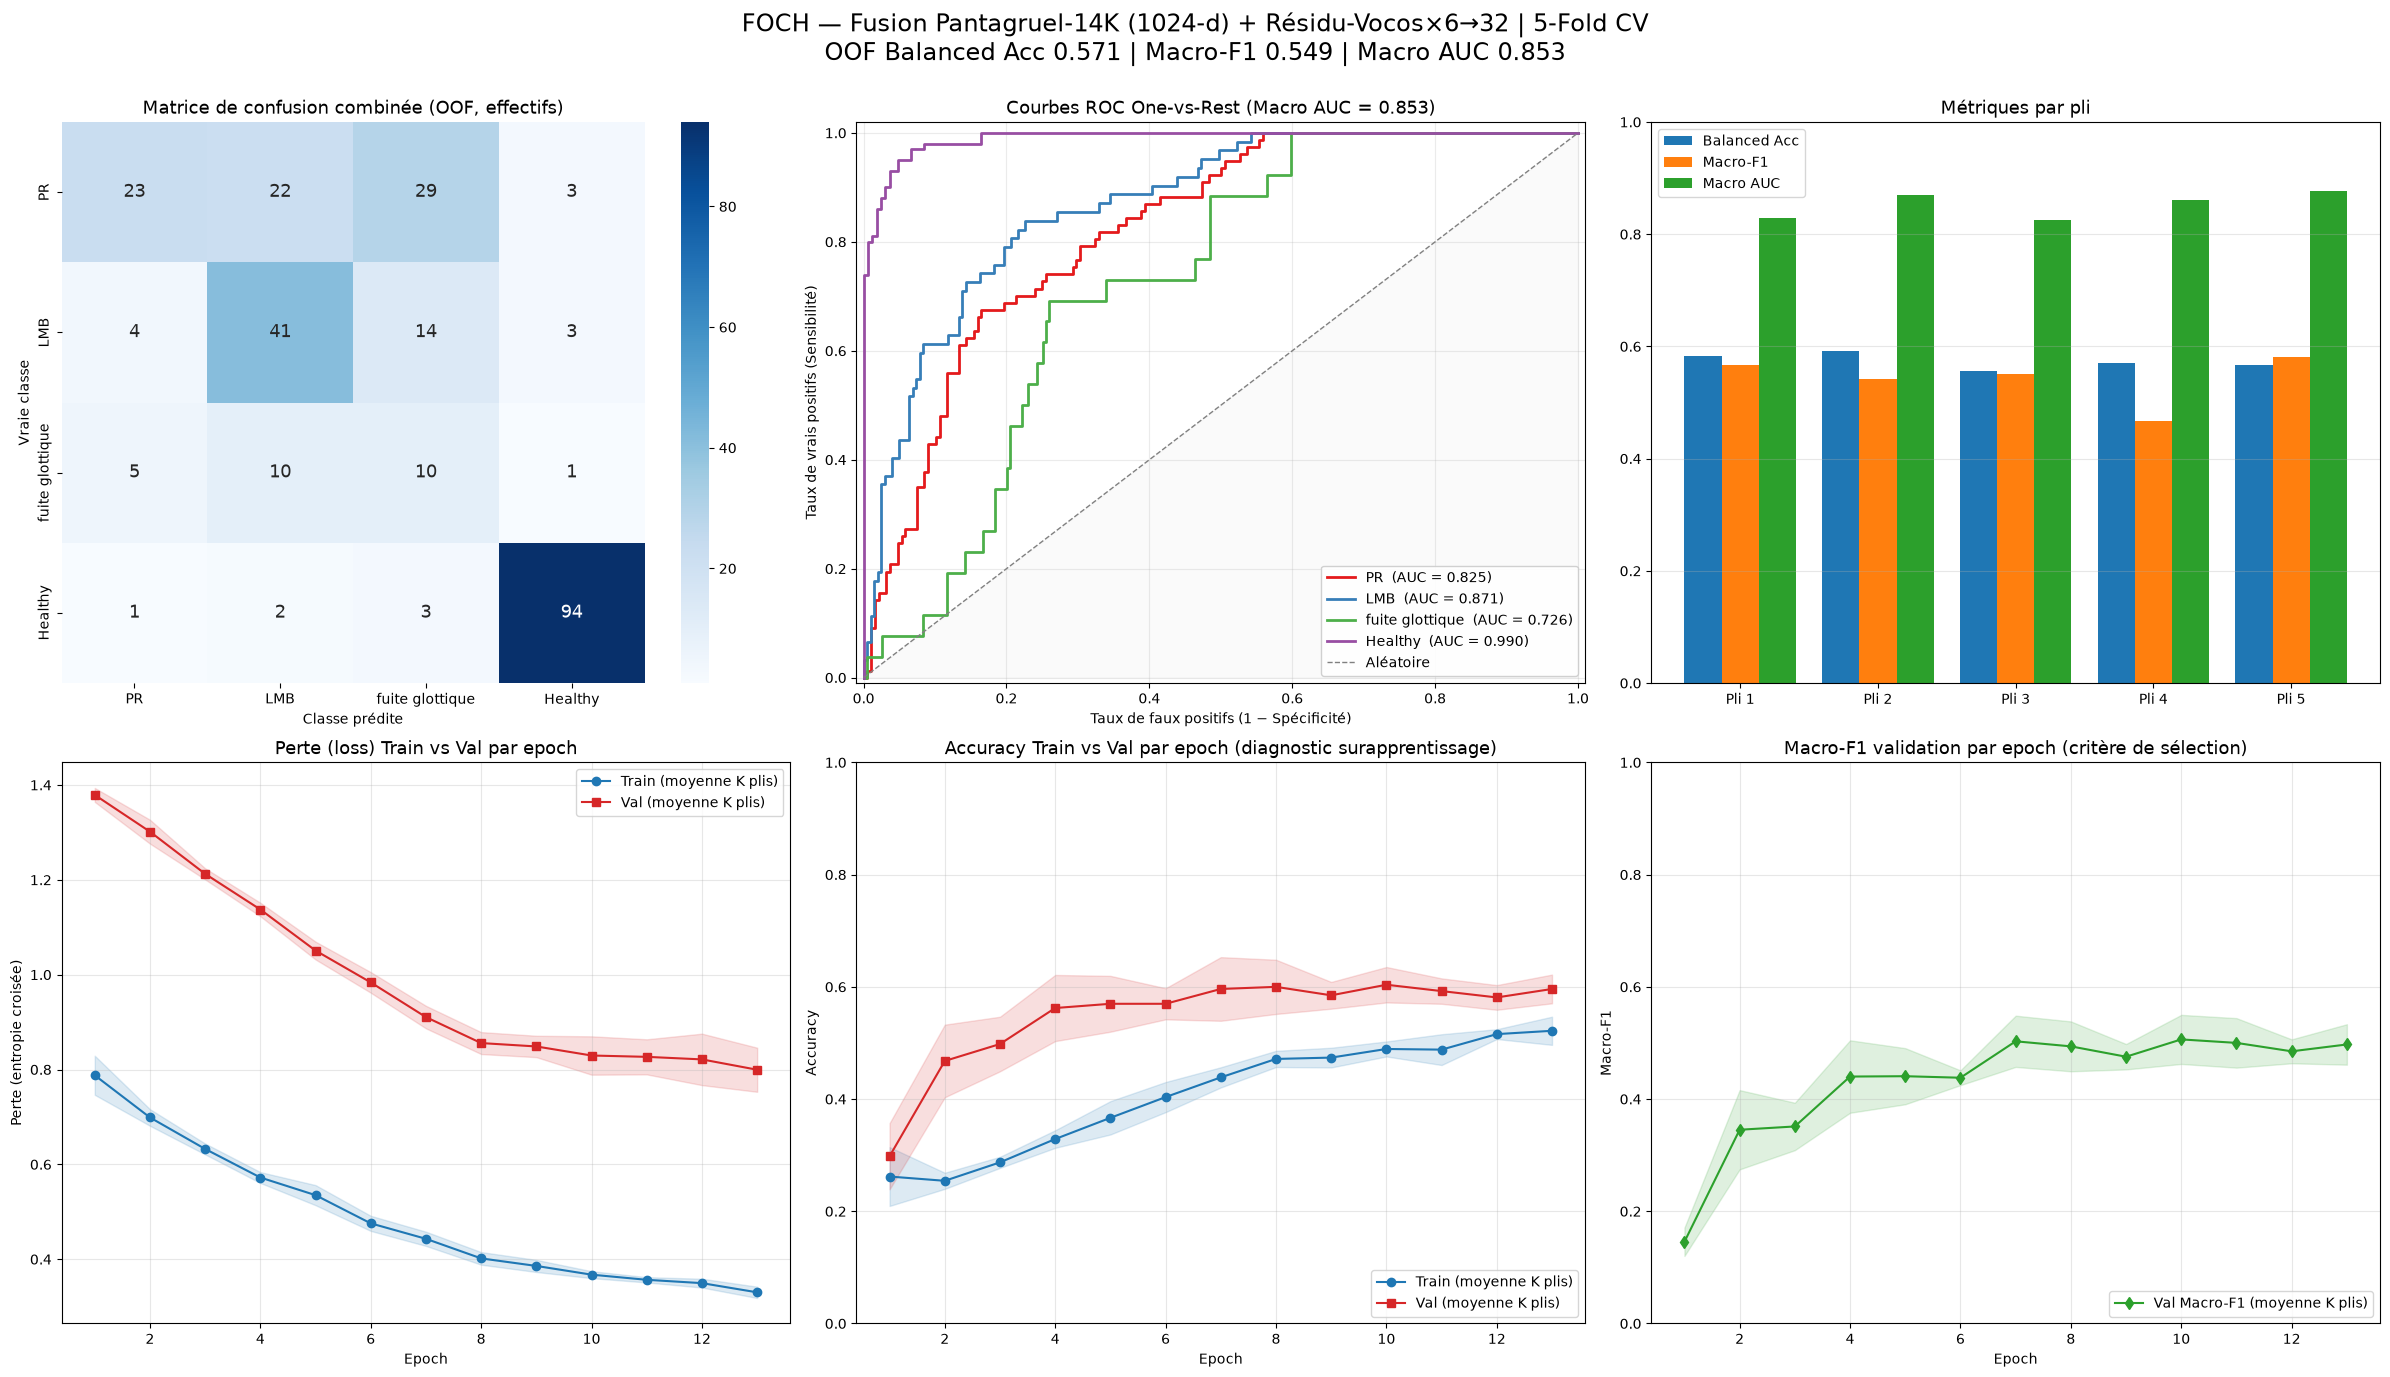


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • pantagruel_residual_kfold_aug_dashboard.png
  • pantagruel_residual_kfold_aug_metrics.json
  • pantagruel_residual_kfold_aug_confusion.csv
  • pantagruel_residual_kfold_aug_fold_metrics.csv


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold) + tableau de bord
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── Titre dynamique : reflète le preset réellement actif ──────────────────────
_arch_names = []
if WAVLM_VARIANT:   _arch_names.append(f'WavLM-{WAVLM_VARIANT.replace("_", "-")}')
if USE_PANTAGRUEL:  _arch_names.append(f'Pantagruel-14K ({PANTAGRUEL_EMB_DIM}-d)')
if USE_RESIDUAL:    _arch_names.append(f'Résidu-Vocos×{N_RESIDUAL_FEATURES}→{RESIDUAL_PROJ_DIM}')
_arch_txt = ' + '.join(_arch_names) if _arch_names else BACKBONE

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Tableau de bord 2×3 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(f'FOCH — Fusion {_arch_txt} | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=17)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 13})
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)', fontsize=13)
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01]); axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})', fontsize=13)
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [0, 2] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[0, 2].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[0, 2].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[0, 2].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[0, 2].set_title('Métriques par pli', fontsize=13)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(True, axis='y', alpha=0.3)

# ── [1, 0] Perte (loss) Train vs Val par epoch ────────────────────────────────
assert 'fold_train_loss' in globals() and len(fold_train_loss), \
    "fold_train_loss manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep_loss = min(min(len(h) for h in fold_train_loss),
                   min(len(h) for h in fold_curves))
tr_loss = np.array([h[:min_ep_loss] for h in fold_train_loss])   # (K, min_ep)
va_loss = np.array([h[:min_ep_loss] for h in fold_curves])
ep_loss = np.arange(1, min_ep_loss + 1)
axes[1, 0].plot(ep_loss, tr_loss.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, tr_loss.mean(0) - tr_loss.std(0), tr_loss.mean(0) + tr_loss.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 0].plot(ep_loss, va_loss.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, va_loss.mean(0) - va_loss.std(0), va_loss.mean(0) + va_loss.std(0),
                        color='#d62728', alpha=0.15)
axes[1, 0].set_title('Perte (loss) Train vs Val par epoch', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Perte (entropie croisée)')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# ── [1, 1] Diagnostic de surapprentissage : Train vs Val accuracy / epoch ─────
assert 'fold_train_acc' in globals() and 'fold_val_acc' in globals() \
        and len(fold_train_acc) and len(fold_val_acc), \
    "fold_train_acc/fold_val_acc manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep = min(min(len(h) for h in fold_train_acc),
             min(len(h) for h in fold_val_acc))
tr = np.array([h[:min_ep] for h in fold_train_acc])   # (K, min_ep)
va = np.array([h[:min_ep] for h in fold_val_acc])
ep = np.arange(1, min_ep + 1)
axes[1, 1].plot(ep, tr.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 1].fill_between(ep, tr.mean(0) - tr.std(0), tr.mean(0) + tr.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 1].plot(ep, va.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 1].fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                        color='#d62728', alpha=0.15)
axes[1, 1].set_title('Accuracy Train vs Val par epoch (diagnostic surapprentissage)', fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# ── [1, 2] Macro-F1 de validation par epoch (critère de sélection) ────────────
# C'est la métrique qui pilote checkpoint et arrêt anticipé (Cellule 7) : la
# tracer explicite ce que l'entraînement a réellement optimisé.
min_ep_f1 = min(len(h) for h in fold_val_f1)
vf1 = np.array([h[:min_ep_f1] for h in fold_val_f1])
ep_f1 = np.arange(1, min_ep_f1 + 1)
axes[1, 2].plot(ep_f1, vf1.mean(0), 'd-', color='#2ca02c', label='Val Macro-F1 (moyenne K plis)')
axes[1, 2].fill_between(ep_f1, vf1.mean(0) - vf1.std(0), vf1.mean(0) + vf1.std(0),
                        color='#2ca02c', alpha=0.15)
axes[1, 2].set_title('Macro-F1 validation par epoch (critère de sélection)', fontsize=13)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Macro-F1')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend(loc='lower right')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           _arch_txt,
    'preset':                 BACKBONE,
    'branches':               {'wavlm': WAVLM_VARIANT, 'pantagruel': USE_PANTAGRUEL, 'residual': USE_RESIDUAL},
    'fusion_dim':             int(FUSION_DIM_EXPECTED),
    'pantagruel_emb_dim':     int(PANTAGRUEL_EMB_DIM),
    'encoders_frozen':        True,
    'residual_features':      list(RESIDUAL_FEATURES) if USE_RESIDUAL else [],
    'residual_proj_dim':      RESIDUAL_PROJ_DIM if USE_RESIDUAL else 0,
    # Statistiques de résidu PAR PLI : leur variation d'un pli à l'autre atteste
    # qu'elles sont calculées sur le seul train, et non globalement.
    'residual_stats_per_fold': fold_residual_stats,
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')

### 8c. Évaluation One-vs-Rest (OvA) et One-vs-One (OvO) — post-hoc sur les prédictions OOF

Décomposition **post-hoc** des métriques agrégées de la Cellule 8 : aucune donnée n'est
ré-entraînée ni ré-inférée ici, on ne fait que recalculer des vues alternatives à partir de
`oof_labels` / `oof_probs` déjà produits par la boucle K-Fold (Cellule 7). Cette cellule doit
donc être exécutée **après** la Cellule 8.

- **One-vs-Rest (OvA)** : pour chaque classe, ROC-AUC, AUC-PR, sensibilité, spécificité, VPP,
  VPN, F1 — table par classe + moyenne macro (non pondérée) et pondérée (par effectif). La
  décision positive/négative par classe réutilise la même règle que le modèle (`argmax` du
  softmax à 4 classes), pas un seuil à 0.5 indépendant par classe.
- **One-vs-One (OvO)** : pour chaque paire non ordonnée de classes, sous-échantillon des seules
  lignes OOF appartenant à l'une des deux classes, puis **couplage pairwise de
  Hastie & Tibshirani (1998)** — `p_i' = p_i / (p_i + p_j)` — plutôt qu'un simple re-softmax :
  cela isole la frontière de décision binaire entre les deux classes de la masse de probabilité
  attribuée aux deux autres classes.
- Les deux fonctions (`ova_evaluation`, `ovo_evaluation`, Cellule ci-dessous) sont **génériques**
  (`y_true`, `y_proba`, `class_names`) et réutilisables telles quelles sur les sorties OOF
  d'autres notebooks de la série `10_x`/`11_x`/`12_x`, pour des comparaisons d'ablation.

> ⚠️ **Niveau patient et corpus — à lire avant d'interpréter les chiffres ci-dessous.**
> - Les classes FOCH (`PR`, `LMB`, `fuite glottique`) sont dédupliquées au niveau patient en
>   amont (`Last_Name`, Cellule 2) : chaque ligne OOF de ces classes correspond à un patient
>   distinct. Pour `Healthy` (SVD), `Last_Name` est en réalité l'identifiant du **dossier
>   d'enregistrement** (`AufnahmeID`), pas celui du locuteur (`SprecherID`) — la garde-fou de
>   déduplication est donc un no-op pour cette classe. Toute métrique OvA/OvO impliquant
>   `Healthy` ci-dessous doit être lue comme du **niveau enregistrement**, pas strictement du
>   niveau patient.
> - `Healthy` est la seule classe issue d'un **corpus différent** (Saarbruecken/SVD) des trois
>   classes pathologiques (FOCH). Toute métrique impliquant `Healthy` peut donc être optimiste —
>   le modèle peut apprendre des artefacts de corpus (chaîne d'enregistrement, bruit de fond,
>   format) plutôt qu'un signal pathologique. Le test honnête serait un ré-entraînement
>   *leave-one-corpus-out* ; il n'est **pas** effectué ici, cette section étant une passe
>   post-hoc sur des OOF déjà calculés, pas un nouvel entraînement. La paire `fuite glottique`
>   ↔ `PR` (Tâche prioritaire ci-dessous) est en revanche **entièrement intra-FOCH** et n'est pas
>   exposée à ce raccourci de corpus — c'est la comparaison la plus fiable de cette section.

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8c — Fonctions OvA / OvO génériques (réutilisables, y_true/y_proba/class_names)
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             accuracy_score, confusion_matrix, roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize


def ova_evaluation(y_true, y_proba, class_names, class_indices=None):
    """One-vs-Rest : table par classe (AUC-ROC, AUC-PR, sensibilité, spécificité, VPP,
    VPN, F1) + moyenne macro et pondérée. La décision par classe réutilise l'argmax du
    softmax multiclasse (comme le modèle), pas un seuil à 0.5 indépendant par classe.
    Retourne (ova_df, macro_row, weighted_row, y_bin)."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if class_indices is None:
        class_indices = np.arange(len(class_names))
    y_pred = y_proba.argmax(axis=1)
    y_bin = label_binarize(y_true, classes=class_indices)
    if y_bin.shape[1] == 1:   # cas dégénéré à 2 classes : label_binarize ne rend qu'une colonne
        y_bin = np.hstack([1 - y_bin, y_bin])
    rows = []
    for i, (cls, idx) in enumerate(zip(class_names, class_indices)):
        yt = y_bin[:, i]
        yp = y_proba[:, idx]
        y_pred_bin = (y_pred == idx).astype(int)
        support = int(yt.sum())
        try:
            auc_roc = roc_auc_score(yt, yp)
        except ValueError:
            auc_roc = float('nan')
        auc_pr = average_precision_score(yt, yp)
        tn, fp, fn, tp = confusion_matrix(yt, y_pred_bin, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else float('nan')
        spec = tn / (tn + fp) if (tn + fp) else float('nan')
        ppv = tp / (tp + fp) if (tp + fp) else float('nan')
        npv = tn / (tn + fn) if (tn + fn) else float('nan')
        f1 = f1_score(yt, y_pred_bin, zero_division=0)
        rows.append(dict(classe=cls, support=support, auc_roc=auc_roc, auc_pr=auc_pr,
                          sensibilite=sens, specificite=spec, ppv=ppv, npv=npv, f1=f1))
    ova_df = pd.DataFrame(rows)
    metric_cols = ['auc_roc', 'auc_pr', 'sensibilite', 'specificite', 'ppv', 'npv', 'f1']
    macro_row = ova_df[metric_cols].mean()
    weighted_row = pd.Series(
        np.average(ova_df[metric_cols].values, axis=0, weights=ova_df['support'].values),
        index=metric_cols)
    return ova_df, macro_row, weighted_row, y_bin


def plot_ova_roc(y_bin, y_proba, class_names, class_indices=None, macro_auc=None, ax=None, title=None):
    """Courbes ROC One-vs-Rest, une ligne par classe, sur un seul axe."""
    if class_indices is None:
        class_indices = np.arange(len(class_names))
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    for i, (cls, idx, col) in enumerate(zip(class_names, class_indices, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, idx])
        auc_i = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')
    ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.02])
    ax.set_xlabel('Taux de faux positifs (1 − Spécificité)')
    ax.set_ylabel('Taux de vrais positifs (Sensibilité)')
    ttl = title or 'Courbes ROC One-vs-Rest'
    if macro_auc is not None:
        ttl += f' (Macro AUC = {macro_auc:.3f})'
    ax.set_title(ttl, fontsize=13)
    ax.legend(loc='lower right', framealpha=0.9)
    ax.grid(True, alpha=0.25)
    return ax


def ovo_evaluation(y_true, y_proba, class_names, class_indices=None):
    """One-vs-One : pour chaque paire non ordonnée (i, j), sous-échantillonne les lignes
    de classe i ou j puis renormalise par couplage pairwise de Hastie & Tibshirani (1998) :
    p_i' = p_i / (p_i + p_j). Calcule AUC, accuracy, sensibilité/spécificité (classe i) sur
    ce sous-ensemble. Retourne (ovo_df, auc_matrix symétrique classes×classes, macro_auc)."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if class_indices is None:
        class_indices = np.arange(len(class_names))
    n = len(class_indices)
    auc_matrix = np.full((n, n), np.nan)
    rows = []
    for a in range(n):
        for b in range(a + 1, n):
            i, j = class_indices[a], class_indices[b]
            mask = np.isin(y_true, [i, j])
            n_pair = int(mask.sum())
            yt_sub = y_true[mask]
            p_i = y_proba[mask, i]
            p_j = y_proba[mask, j]
            denom = p_i + p_j
            denom = np.where(denom <= 0, 1e-12, denom)
            p_i_prime = p_i / denom
            y_bin = (yt_sub == i).astype(int)
            try:
                pair_auc = roc_auc_score(y_bin, p_i_prime)
            except ValueError:
                pair_auc = float('nan')
            y_pred_bin = (p_i_prime >= 0.5).astype(int)
            acc = accuracy_score(y_bin, y_pred_bin)
            tn, fp, fn, tp = confusion_matrix(y_bin, y_pred_bin, labels=[0, 1]).ravel()
            sens = tp / (tp + fn) if (tp + fn) else float('nan')
            spec = tn / (tn + fp) if (tn + fp) else float('nan')
            rows.append(dict(classe_i=class_names[a], classe_j=class_names[b], n_pair=n_pair,
                              auc=pair_auc, accuracy=acc, sensibilite_i=sens, specificite_i=spec))
            auc_matrix[a, b] = auc_matrix[b, a] = pair_auc
    ovo_df = pd.DataFrame(rows)
    macro_auc = ovo_df['auc'].mean()
    return ovo_df, auc_matrix, macro_auc


def plot_ovo_heatmap(auc_matrix, class_names, ax=None, title='Matrice AUC pairwise (One-vs-One)'):
    """Heatmap symétrique classes × classes des AUC pairwise (diagonale masquée)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 5.5))
    diag_mask = np.eye(len(class_names), dtype=bool)
    sns.heatmap(auc_matrix, annot=True, fmt='.3f', cmap='viridis', vmin=0.5, vmax=1.0,
                xticklabels=class_names, yticklabels=class_names, mask=diag_mask,
                ax=ax, cbar_kws={'label': 'AUC'}, annot_kws={'size': 11})
    ax.set_title(title, fontsize=13)
    return ax


print('Fonctions OvA/OvO chargées : ova_evaluation, plot_ova_roc, ovo_evaluation, plot_ovo_heatmap.')

Fonctions OvA/OvO chargées : ova_evaluation, plot_ova_roc, ovo_evaluation, plot_ovo_heatmap.


Évaluation One-vs-Rest (OvR) par classe — dérivée post-hoc des prédictions OOF :

         classe  support  auc_roc  auc_pr  sensibilite  specificite    ppv    npv     f1
             PR       77   0.8247  0.6029       0.2987       0.9468 0.6970 0.7672 0.4182
            LMB       62   0.8714  0.6587       0.6613       0.8325 0.5467 0.8895 0.5985
fuite glottique       26   0.7263  0.1871       0.3846       0.8075 0.1786 0.9234 0.2439
        Healthy      100   0.9900  0.9844       0.9400       0.9576 0.9307 0.9634 0.9353

Moyenne macro (non pondérée) :
auc_roc        0.8531
auc_pr         0.6083
sensibilite    0.5712
specificite    0.8861
ppv            0.5882
npv            0.8859
f1             0.5490

Moyenne pondérée (par effectif) :
auc_roc        0.8884
auc_pr         0.7191
sensibilite    0.6340
specificite    0.9105
ppv            0.6991
npv            0.8852
f1             0.6384

Contrôle croisé — Macro AUC OvR (fonctions ci-dessus) : 0.853093
Contrôle croisé — Macro AUC OvR 

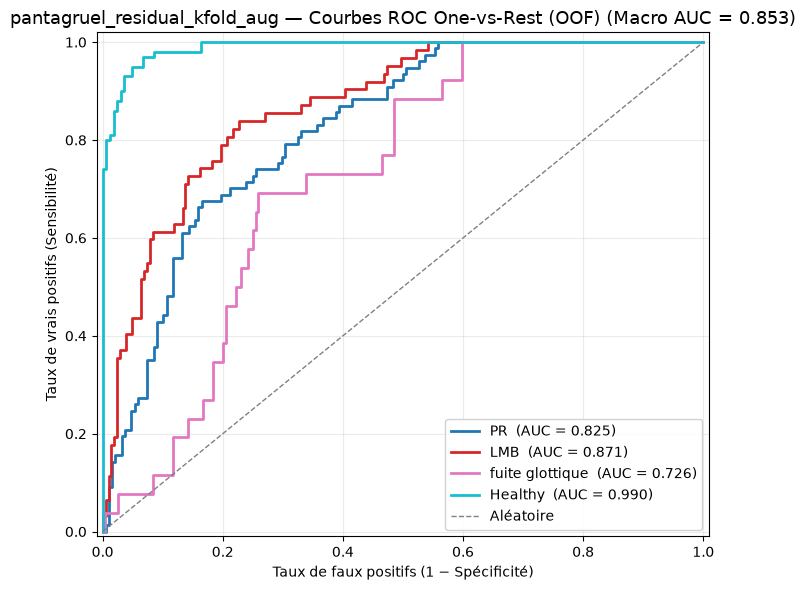


Figure sauvegardée : C:/Users/AdminIA/Documents/models/.foch_métriques\pantagruel_residual_kfold_aug_ova_roc.png


In [13]:
# ── Application OvA sur les OOF de ce run ─────────────────────────────────────
ova_df, ova_macro, ova_weighted, oof_labels_bin_ova = ova_evaluation(
    oof_labels, oof_probs, CLASSES, labels_idx)

print("Évaluation One-vs-Rest (OvR) par classe — dérivée post-hoc des prédictions OOF :\n")
print(ova_df.round(4).to_string(index=False))
print('\nMoyenne macro (non pondérée) :')
print(ova_macro.round(4).to_string())
print('\nMoyenne pondérée (par effectif) :')
print(ova_weighted.round(4).to_string())

ova_macro_auc = float(ova_macro['auc_roc'])
sk_ovr_macro = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                             average='macro', labels=labels_idx)
print(f"\nContrôle croisé — Macro AUC OvR (fonctions ci-dessus) : {ova_macro_auc:.6f}")
print(f"Contrôle croisé — Macro AUC OvR (sklearn roc_auc_score)  : {sk_ovr_macro:.6f}")
assert np.isclose(ova_macro_auc, sk_ovr_macro, atol=1e-9), \
    "Divergence inattendue avec sklearn — vérifier l'implémentation OvR."
print("✓ Les deux calculs concordent (même méthode : moyenne non pondérée des AUC "
      "binaires par classe).")

fig, ax = plt.subplots(figsize=(7, 6))
plot_ova_roc(oof_labels_bin_ova, oof_probs, CLASSES, labels_idx, macro_auc=ova_macro_auc, ax=ax,
             title=f'{RUN_NAME} — Courbes ROC One-vs-Rest (OOF)')
plt.tight_layout()
ova_fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_ova_roc.png')
plt.savefig(ova_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFigure sauvegardée : {ova_fig_path}')

Évaluation One-vs-One (OvO) par paire de classes — couplage pairwise Hastie-Tibshirani
(p_i' = p_i / (p_i + p_j), pas un simple re-softmax) — dérivée post-hoc des OOF :

       classe_i        classe_j  n_pair    auc  accuracy  sensibilite_i  specificite_i
             PR             LMB     139 0.7884    0.6978         0.5844         0.8387
             PR fuite glottique     103 0.4790    0.4466         0.4026         0.5769
             PR         Healthy     177 0.9900    0.9492         0.9221         0.9700
            LMB fuite glottique      88 0.7239    0.6705         0.7258         0.5385
            LMB         Healthy     162 0.9900    0.9444         0.9355         0.9500
fuite glottique         Healthy     126 0.9900    0.9603         0.9615         0.9600

Macro AUC OvO (couplage pairwise, 6 paires) : 0.8269
Contrôle croisé — Macro AUC OvO (sklearn roc_auc_score, colonnes brutes) : 0.8138
ℹ️  Un écart entre ces deux valeurs est attendu, ce n'est pas une erreur : sklearn mo

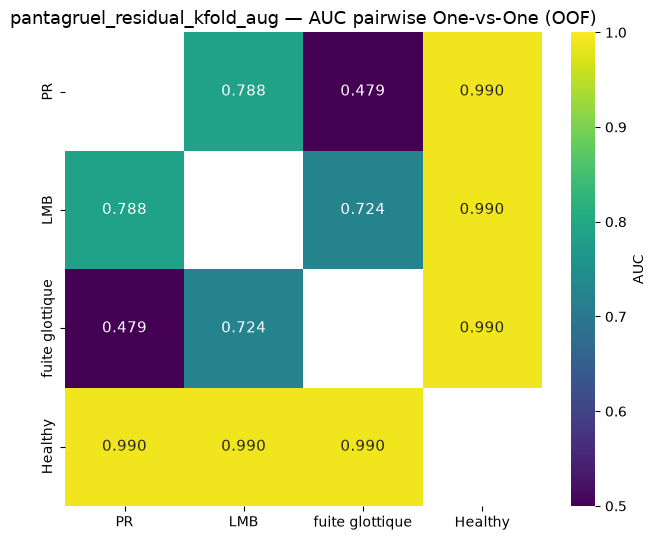


Figure sauvegardée : C:/Users/AdminIA/Documents/models/.foch_métriques\pantagruel_residual_kfold_aug_ovo_heatmap.png

Paire cliniquement prioritaire — fuite glottique ↔ PR (confusion connue) :
  Effectif dans la sous-population (i∪j) : 103
  AUC pairwise (couplage)                : 0.4790
  Accuracy pairwise                      : 0.4466
  Sensibilité / Spécificité (classe i)   : 0.4026 / 0.5769


In [14]:
# ── Application OvO sur les OOF de ce run ─────────────────────────────────────
# Paire cliniquement prioritaire : ne changer que cette ligne pour réutiliser
# la section sur un autre notebook de la série 10_x/11_x/12_x.
PRIORITY_PAIR = ('fuite glottique', 'PR')

ovo_df, ovo_auc_matrix, ovo_macro_auc = ovo_evaluation(oof_labels, oof_probs, CLASSES, labels_idx)

print("Évaluation One-vs-One (OvO) par paire de classes — couplage pairwise Hastie-Tibshirani\n"
      "(p_i' = p_i / (p_i + p_j), pas un simple re-softmax) — dérivée post-hoc des OOF :\n")
print(ovo_df.round(4).to_string(index=False))

print(f"\nMacro AUC OvO (couplage pairwise, {len(ovo_df)} paires) : {ovo_macro_auc:.4f}")

sk_ovo_macro = roc_auc_score(oof_labels, oof_probs, multi_class='ovo',
                             average='macro', labels=labels_idx)
print(f"Contrôle croisé — Macro AUC OvO (sklearn roc_auc_score, colonnes brutes) : {sk_ovo_macro:.4f}")
print("ℹ️  Un écart entre ces deux valeurs est attendu, ce n'est pas une erreur : sklearn moyenne\n"
      "   l'AUC calculée séparément sur les colonnes de probabilité brutes p_i et p_j (deux calculs\n"
      "   asymétriques par paire), alors que le couplage pairwise Hastie-Tibshirani renormalise\n"
      "   p_i' = p_i / (p_i + p_j) *avant* l'AUC — isolant la frontière de décision binaire entre les\n"
      "   deux classes de la masse de probabilité attribuée aux autres classes. C'est le couplage\n"
      "   pairwise qui est la métrique demandée dans cette section.")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_ovo_heatmap(ovo_auc_matrix, CLASSES, ax=ax, title=f'{RUN_NAME} — AUC pairwise One-vs-One (OOF)')
plt.tight_layout()
ovo_fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_ovo_heatmap.png')
plt.savefig(ovo_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFigure sauvegardée : {ovo_fig_path}')

# ── Paire cliniquement prioritaire ─────────────────────────────────────────────
_pair_mask = ((ovo_df['classe_i'] == PRIORITY_PAIR[0]) & (ovo_df['classe_j'] == PRIORITY_PAIR[1])) | \
             ((ovo_df['classe_i'] == PRIORITY_PAIR[1]) & (ovo_df['classe_j'] == PRIORITY_PAIR[0]))
fg_pr_row = ovo_df[_pair_mask]
if len(fg_pr_row):
    r = fg_pr_row.iloc[0]
    print('\n' + '=' * 70)
    print(f"Paire cliniquement prioritaire — {PRIORITY_PAIR[0]} ↔ {PRIORITY_PAIR[1]} (confusion connue) :")
    print('=' * 70)
    print(f"  Effectif dans la sous-population (i∪j) : {int(r['n_pair'])}")
    print(f"  AUC pairwise (couplage)                : {r['auc']:.4f}")
    print(f"  Accuracy pairwise                      : {r['accuracy']:.4f}")
    print(f"  Sensibilité / Spécificité (classe i)   : {r['sensibilite_i']:.4f} / {r['specificite_i']:.4f}")
else:
    print(f"⚠ Paire {PRIORITY_PAIR} introuvable — vérifier CLASSES / PRIORITY_PAIR.")

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8c (suite) — Synthèse comparative OvA / OvO / multiclasse poolé
# ═══════════════════════════════════════════════════════════════════════════
summary_rows = [
    {'méthode': 'Multiclasse poolé (OvR interne, Cellule 8)',        'macro_auc': oof_auc,      'n_comparaisons': len(CLASSES)},
    {'méthode': 'One-vs-Rest (fonctions Cellule 8c)',                'macro_auc': ova_macro_auc, 'n_comparaisons': len(CLASSES)},
    {'méthode': 'One-vs-One (couplage pairwise Hastie-Tibshirani)',  'macro_auc': ovo_macro_auc, 'n_comparaisons': len(ovo_df)},
    {'méthode': 'One-vs-One (sklearn, colonnes brutes)',             'macro_auc': sk_ovo_macro,  'n_comparaisons': len(ovo_df)},
]
summary_df = pd.DataFrame(summary_rows)
print('Synthèse comparative — AUC macro par méthode :\n')
print(summary_df.round(4).to_string(index=False))

# ── Interprétation dynamique — recalculée à partir des valeurs ci-dessus, jamais figée ──
_fg_pr_auc = float(fg_pr_row.iloc[0]['auc']) if len(fg_pr_row) else float('nan')
_fg_idx = CLASSES.index(PRIORITY_PAIR[0])
_pr_idx = CLASSES.index(PRIORITY_PAIR[1])
_cm_confused = int(cm[_fg_idx, _pr_idx] + cm[_pr_idx, _fg_idx])
_cm_total_pair = int(cm[_fg_idx, :].sum() + cm[_pr_idx, :].sum())
_confusion_rate = _cm_confused / _cm_total_pair if _cm_total_pair else float('nan')
_sens = 'plus' if _fg_pr_auc > oof_auc else 'moins'

if _fg_pr_auc < 0.80:
    _interp_detail = (
        "la paire reste difficile à séparer même isolée des deux autres classes (Healthy, LMB) : "
        "la confusion observée dans la matrice combinée n'est donc pas un simple artefact de la "
        "compétition à 4 classes, et une branche discriminante dédiée (résidu vocodeur ou "
        "bioacoustique) reste justifiée pour cette paire spécifiquement."
    )
else:
    _interp_detail = (
        "la séparabilité en isolation est notablement meilleure que ne le suggère la matrice "
        "combinée : une partie de la confusion poolée provient donc probablement de la "
        "compétition avec les deux autres classes (Healthy, LMB) plutôt que d'une frontière de "
        "décision intrinsèquement floue entre les deux classes elles-mêmes."
    )

print('\n' + '=' * 70)
print('Interprétation :')
print('=' * 70)
print(
    f"L'AUC pairwise isolée {PRIORITY_PAIR[0]} ↔ {PRIORITY_PAIR[1]} ({_fg_pr_auc:.3f}) est {_sens} "
    f"élevée que l'AUC multiclasse poolée ({oof_auc:.3f}). Dans la matrice de confusion combinée, "
    f"{_cm_confused} enregistrement(s) sur {_cm_total_pair} impliquant l'une de ces deux classes "
    f"sont confondus entre elles (taux {_confusion_rate:.1%}) : {_interp_detail}"
)
print(
    "\n⚠️  Rappel méthodologique — Healthy provient d'un corpus distinct (Saarbruecken/SVD) des "
    "trois classes pathologiques (FOCH) ; les métriques OvA/OvO impliquant Healthy ci-dessus "
    "peuvent donc être optimistes (artefacts de corpus plutôt que signal pathologique) et n'ont "
    f"pas été vérifiées en leave-one-corpus-out ici. La paire {PRIORITY_PAIR[0]} ↔ {PRIORITY_PAIR[1]}, "
    "elle, est entièrement intra-FOCH et n'est pas exposée à ce raccourci de corpus — c'est la "
    "comparaison la plus fiable de cette section."
)

# ── Sauvegarde ──────────────────────────────────────────────────────────────
summary_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_ova_ovo_summary.csv'), index=False)
ova_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_ova_per_class.csv'), index=False)
ovo_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_ovo_pairs.csv'), index=False)
print(f"\nArtefacts sauvegardés dans {METRICS_DIR} :")
print(f'  • {RUN_NAME}_ova_roc.png')
print(f'  • {RUN_NAME}_ovo_heatmap.png')
print(f'  • {RUN_NAME}_ova_ovo_summary.csv')
print(f'  • {RUN_NAME}_ova_per_class.csv')
print(f'  • {RUN_NAME}_ovo_pairs.csv')

Synthèse comparative — AUC macro par méthode :

                                         méthode  macro_auc  n_comparaisons
      Multiclasse poolé (OvR interne, Cellule 8)     0.8531               4
              One-vs-Rest (fonctions Cellule 8c)     0.8531               4
One-vs-One (couplage pairwise Hastie-Tibshirani)     0.8269               6
           One-vs-One (sklearn, colonnes brutes)     0.8138               6

Interprétation :
L'AUC pairwise isolée fuite glottique ↔ PR (0.479) est moins élevée que l'AUC multiclasse poolée (0.853). Dans la matrice de confusion combinée, 34 enregistrement(s) sur 103 impliquant l'une de ces deux classes sont confondus entre elles (taux 33.0%) : la paire reste difficile à séparer même isolée des deux autres classes (Healthy, LMB) : la confusion observée dans la matrice combinée n'est donc pas un simple artefact de la compétition à 4 classes, et une branche discriminante dédiée (résidu vocodeur ou bioacoustique) reste justifiée pour cette pai

### 8b. Journal persistant des runs (branches, augmentations, métriques)

La Cellule 8 écrit `{RUN_NAME}_metrics.json` / `_fold_metrics.csv` : un seul
fichier par preset, écrasé à chaque nouvelle exécution du même `BACKBONE`.
Utile pour l'inspection d'un run précis, mais rien ne survit d'une exécution
à l'autre pour comparer les presets entre eux.

La cellule suivante ajoute **une ligne par exécution** à un CSV unique et
persistant (`runs_log.csv`, dans le dossier du notebook) : preset de branches actives,
types d'augmentation activés (`AUG_TYPES_ENABLED`), hyperparamètres et
métriques OOF. Exécuter cette cellule **après** la Cellule 8 (elle lit
`oof_bal`, `mean_f1`, `fold_df`, etc. déjà calculés) à chaque fois qu'un run
complet doit être archivé. Le fichier n'est jamais écrasé : chaque exécution
relit le CSV existant, concatène la nouvelle ligne, puis réécrit l'ensemble
(alignement par nom de colonne, `sort=False`) — ce qui tolère l'ajout futur
d'un preset, d'un type d'augmentation ou d'un hyperparamètre sans casser
l'historique déjà journalisé.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════════
# Cellule 8b — Journal persistant des runs (branches, augmentations, métriques)
# ══════════════════════════════════════════════════════════════════════════════════
import datetime
import os
from pathlib import Path

# ── Résolution du dossier du notebook (même dossier que ce .ipynb) ─────────────
# Cette logique fonctionne aussi bien si le notebook est lancé depuis la racine
# du repo ou depuis le dossier pantagruel lui-même.
def _resolve_notebook_dir():
    candidates = [Path.cwd(), Path.cwd() / 'pantagruel', Path.cwd().parent / 'pantagruel']
    candidates.append(Path(r'C:/Users/AdminIA/Desktop/Foch_Classif_Final/pantagruel'))
    for candidate in candidates:
        if (candidate / '10_0_foch_test_pantagruel.ipynb').exists():
            return candidate.resolve()
    return Path.cwd().resolve()

NOTEBOOK_DIR = _resolve_notebook_dir()
RUNS_LOG_PATH = os.path.join(str(NOTEBOOK_DIR), 'runs_log.csv')

# ── Une ligne = un run ─────────────────────────────────────────────────────────────────────────────
# Branches actives : dérivées du preset BACKBONE (Cellule 1), jamais réécrites à
# la main ici — on journalise ce qui a réellement tourné, pas une étiquette.
# Augmentations : AUG_TYPES_ENABLED reflète le sous-ensemble réellement injecté
# en train (Cellule 5), 'aucune' si l'ensemble est vide.
run_record = {
    'run_id':                  None,   # rempli plus bas (compteur du journal)
    'timestamp':               datetime.datetime.now().isoformat(timespec='seconds'),
    'run_name':                RUN_NAME,
    'preset':                  BACKBONE,
    'wavlm_variant':           WAVLM_VARIANT,
    'use_pantagruel':          USE_PANTAGRUEL,
    'use_residual':            USE_RESIDUAL,
    'fusion_dim':              int(FUSION_DIM_EXPECTED),
    'aug_types_enabled':       '+'.join(sorted(AUG_TYPES_ENABLED)) if AUG_TYPES_ENABLED else 'aucune',
    'finetune_scope':          'tete_fusion+proj_residu (encodeurs geles)',
    'k_folds':                 K_FOLDS,
    'max_len_s':               MAX_LEN_S,
    'batch_size':              BATCH_SIZE,
    'accum_steps':             ACCUM_STEPS,
    'effective_batch':         BATCH_SIZE * ACCUM_STEPS,
    'epochs_max':              EPOCHS,
    'lr':                      LR,
    'weight_decay':            WEIGHT_DECAY,
    'dropout':                 DROPOUT,
    'hidden_dim':              HIDDEN_DIM,
    'input_dropout':           INPUT_DROPOUT,
    'focal_gamma':             FOCAL_GAMMA,
    'n_total':                 int(len(df)),
    'n_healthy_target':        N_HEALTHY,
    'oof_balanced_accuracy':   oof_bal,
    'oof_macro_f1':            oof_mf1,
    'oof_macro_auc_ovr':       oof_auc,
    'mean_balanced_accuracy':  mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':           mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':      mean_auc, 'std_macro_auc_ovr':     std_auc,
    'notes':                   '',   # champ libre — à compléter à la main après coup si besoin
}

new_row = pd.DataFrame([run_record])

# ── Lecture-concaténation-réécriture, jamais un append brut ────────────────
# Un append brut (mode='a') suppose un en-tête FIGE : la première ligne écrite
# fixerait les colonnes pour toujours. En relisant puis en concaténant avec
# sort=False, une colonne ajoutée plus tard (nouveau preset, nouvel
# hyperparamètre) s'insère proprement — NaN pour les runs passés qui ne
# l'avaient pas — sans invalider l'historique déjà écrit sur disque. Le coût
# (relire tout le CSV à chaque run) est négligeable : un run = une ligne.
if os.path.isfile(RUNS_LOG_PATH):
    runs_log = pd.read_csv(RUNS_LOG_PATH)
    if 'run_id' not in runs_log.columns:
        runs_log['run_id'] = range(1, len(runs_log) + 1)
    next_run_id = int(runs_log['run_id'].max()) + 1 if len(runs_log) else 1
    new_row['run_id'] = next_run_id
    runs_log = pd.concat([runs_log, new_row], ignore_index=True, sort=False)
else:
    new_row['run_id'] = 1
    runs_log = new_row

runs_log.to_csv(RUNS_LOG_PATH, index=False)

print(f"Run \"{RUN_NAME}\" (id {int(new_row['run_id'].iloc[0])}) ajouté au journal "
      f"— {len(runs_log)} run(s) au total → {RUNS_LOG_PATH}")
runs_log[['run_id', 'timestamp', 'run_name', 'preset', 'aug_types_enabled',
          'oof_balanced_accuracy', 'oof_macro_f1', 'oof_macro_auc_ovr']].tail(5)

Run "pantagruel_residual_kfold_aug" (id 47) ajouté au journal — 47 run(s) au total → C:\Users\AdminIA\Desktop\Foch_Classif_Final\pantagruel\runs_log.csv


,run_id,timestamp,run_name,preset,aug_types_enabled,oof_balanced_accuracy,oof_macro_f1,oof_macro_auc_ovr
42,43,2026-08-25T16:55:41,pantagruel_wavlm_bp_kfold_aug,pantagruel_wavlm_bp,h_vc+signal,0.643443,0.634462,0.860163
43,44,2026-08-26T09:56:15,pantagruel_solo_kfold_aug,pantagruel_solo,h_vc+signal,0.583324,0.550444,0.834659
44,45,2026-08-26T10:15:43,wavlm_bp_solo_kfold_aug,wavlm_bp_solo,h_vc+signal,0.484152,0.461109,0.739215
45,46,2026-08-26T10:57:51,wavlm_la_solo_kfold_aug,wavlm_la_solo,h_vc+signal,0.638200,0.597676,0.832677
46,47,2026-08-26T16:54:09,pantagruel_residual_kfold_aug,pantagruel_residual,h_vc+signal,0.571152,0.548987,0.853093


## 9. Synthèse et prochaines étapes

Ce notebook met en œuvre un **classifieur tri-branche configurable** (préréglages `BACKBONE`, Cellule 1) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli dans le seul jeu d'entraînement. Les trois branches — WavLM Base-Plus, Pantagruel `speech-large-14K`, résidu vocodeur (Vocos, log-mel) — partagent la même boucle d'entraînement (Cellule 7) et le même `Dataset` (Cellule 4) ; seule la dimension de fusion s'adapte automatiquement aux branches actives (`MultiBranchFusion`, Cellule 6).

**Configuration active : `BACKBONE = 'pantagruel_wavlm_bp_residual'`** → WavLM Base-Plus (768-d, gelé) ⊕ Pantagruel-14K (dimension résolue à l'exécution, gelé) ⊕ projection du résidu vocodeur (`RESIDUAL_PROJ_DIM`-d, entraînable).

> ℹ️ **Aucun résultat chiffré n'est reporté ici.** Les métriques de ce notebook sont produites par l'exécution (Cellules 7 et 8) et écrites dans `.foch_métriques`. Les chiffres des notebooks antérieurs — y compris les versions précédentes de ce même notebook avec la branche bioacoustique — décrivent d'autres architectures et ne constituent pas une référence valide pour celle-ci ; la seule comparaison légitime est celle des presets de **ce** notebook entre eux, tous évalués sur les mêmes plis et la même graine.

**Choix méthodologiques clés :**
- **Appariement linguistique** : Pantagruel est pré-entraîné sur ~14 000 h de parole française, là où WavLM (anglais) et les backbones AudioSet des notebooks précédents subissaient un décalage de domaine face à un corpus francophone. Ce gain ne coûte aucun paramètre entraînable puisque l'encodeur reste gelé.
- **Complémentarité plutôt qu'arbitrage** : WavLM Base-Plus (objectif de débruitage/mélange de locuteurs → détail microscopique) et Pantagruel (représentation phonétique/prosodique française) sont concaténés ; les presets solo mesurent l'apport réel de chacun.
- **Résolution de dimension à l'exécution** : la dimension de Pantagruel est lue depuis `config.embed_dim` (et non `hidden_size`, valeur héritée inutilisée), puis **revérifiée sur une passe avant réelle** avec assertion bloquante — aucune dimension n'est écrite en dur.
- **Fine-tuning limité à la tête** : les deux encodeurs sont intégralement gelés, ~300 échantillons d'entraînement ne pouvant remodeler 407 M paramètres. Le notebook ne contient **aucune** logique de dégel progressif : elle a été retirée du code, pas désactivée.
- **Branche résidu vocodeur, en domaine log-mel** : un vocodeur neuronal pré-entraîné et gelé (Vocos) resynthétise chaque enregistrement à partir de son propre mel ; l'écart mel original ↔ mel resynthétisé, résumé par 6 statistiques (énergie, profil bande grave/médiane/aiguë, platitude spectrale, entropie temporelle), remplace les descripteurs Praat de la version précédente de ce notebook. Comparaison faite en log-mel plutôt qu'en forme d'onde brute : le résidu temporel s'est révélé, empiriquement, dominé par un désaccord de phase plutôt que par un signal exploitable (`vocoder_residual_exploration.ipynb`, Section 5) — cf. journal des modifications ci-dessous pour le raisonnement complet et les questions restées ouvertes.
- **Validation croisée sans fuite** : déduplication patient en amont, augmentation injectée dans le seul train après exclusion des patients de validation (assertion), poids de classes **et** statistiques de résidu vocodeur recalculés sur le seul `train_full` de chaque pli.

**Pistes d'amélioration ultérieures :**
1. **Exécuter la grille d'ablation** (`pantagruel_solo`, `wavlm_bp_solo`, `residual_solo`, `pantagruel_wavlm_bp`, puis le preset complet) — même graine, mêmes plis — pour attribuer le gain à chaque branche plutôt qu'au tout.
2. **Comparer directement à l'ancienne branche bioacoustique** (versions antérieures de ce notebook, ou en réintroduisant `_BIO_EXTRACTORS` sous un preset dédié) sur les mêmes plis : la branche résidu vocodeur est une hypothèse plus indirecte que les mesures Praat établies (jitter/shimmer/HNR/CPPS ciblent spécifiquement `fuite glottique` ↔ `PR`), et son intérêt réel reste à démontrer, pas supposé.
3. **Examiner le bloc `PR` ↔ `fuite glottique`** de la matrice de confusion avec et sans branche résidu vocodeur.
4. **Multi-vocodeur** — vérifier si le résidu et son éventuel contenu pathologique sont stables selon le vocodeur choisi (Vocos vs. HiFi-GAN vs. BigVGAN) ou s'ils sont un artefact du seul Vocos (question ouverte de `vocoder_residual_exploration.ipynb`, jamais tranchée).
5. **Pondération par couche de Pantagruel** — au lieu de la dernière couche seule, apprendre une combinaison convexe des 16 couches (à la ELMo/SUPERB) : les couches intermédiaires portent souvent davantage d'information paralinguistique que la dernière, sans dégeler quoi que ce soit.
6. **Mise en cache disque des embeddings gelés** — WavLM et Pantagruel étant figés, leurs sorties sont constantes d'une époque à l'autre : les précalculer une fois (comme le résidu vocodeur l'est déjà, en mémoire) supprimerait l'essentiel du coût de chaque exécution.
7. **Ensembling** des K modèles de plis à l'inférence.
8. **Audit qualité** des doublons d'homonymes (`Last_Name` est un proxy patient imparfait) via `patient_id`.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8, plus 4b). Tous les modèles sont chargés **localement** (`HF_HUB_OFFLINE=1`, `local_files_only=True`) : aucune connexion à `huggingface.co` n'est tentée. Pantagruel requiert `trust_remote_code=True` **et** le paquet `timm` dans l'environnement `.aug` (importé par `modeling_pantagruel_uni.py`). La Cellule 7 entraîne **K = 5 modèles** : prévoir un GPU CUDA et un temps d'exécution conséquent — le premier pli paie en plus le calcul du résidu vocodeur (CPU, ~30-50 ms/clip), mis en cache ensuite.

## Journal des modifications

- **2026-08-03 — Remplacement de la branche bioacoustique (Praat) par un résidu vocodeur (Vocos, log-mel).**
  - **Pourquoi** : ouvrir une hypothèse alternative à la branche bioacoustique explicite — un vocodeur neuronal pré-entraîné sur de la parole saine encode implicitement ce à quoi ressemble une phonation « typique » ; ce qu'il ne reproduit pas fidèlement pourrait être corrélé à l'irrégularité pathologique, sans formuler à la main les mesures cliniques (jitter/shimmer/HNR/CPPS) que la branche précédente ciblait.
  - **Domaine log-mel, pas forme d'onde brute** : `vocoder/vocoder_residual_exploration.ipynb` (Section 5) a mesuré, sur de vrais /a/ FOCH/SVD, un résidu temporel `e(t) = x(t) - x̂(t)` dont le RMS est *supérieur* à celui de l'original sur tous les groupes testés (ratio ~1.1-1.5) — Vocos étant optimisé sur une perte spectrale et non sur une reconstruction de phase échantillon-exacte, ce résidu est dominé par un désaccord de phase, pas par un signal d'erreur exploitable tel quel. Le domaine mel (log-magnitude, sans phase) rend la comparaison honnête : `mel_orig = vocos.feature_extractor(x)`, `mel_resynth = vocos.feature_extractor(vocos.decode(mel_orig))`, `residual_mel = mel_orig - mel_resynth` (les deux mel tronqués au nombre de trames commun le plus court, comme la troncature en échantillons de l'exploration).
  - **Log-scaling confirmé, pas supposé** : lecture de `vocos/feature_extractors.py` (`MelSpectrogramFeatures.forward`) — `features = safe_log(mel)` est bien appliqué par `vocos.feature_extractor()`, donc `mel_orig` et `mel_resynth` sont déjà comparables en soustraction directe.
  - **6 features fixes** (`RESIDUAL_FEATURES`, Cellule 1) résument `residual_mel` : énergie globale, moyenne `|résidu|` par tiers de bandes mel (grave/médian/aigu), platitude spectrale (entropie de Wiener) du profil bande-résidu, entropie temporelle normalisée de l'enveloppe d'énergie — dimensionnalité volontairement dans le même ordre de grandeur que les 6 descripteurs Praat remplacés (contrainte explicite : ~300 échantillons d'entraînement, pas de budget pour une branche haute dimension).
  - **Précalcul en cache, pas de calcul à la volée** (`RESIDUAL_CACHE_ENABLED=True`, Cellule 1) : ce notebook injecte l'augmentation via des fichiers pré-générés statiques (`AUG_MANIFESTS`), pas via une transformation de forme d'onde à la volée (contrairement à `9_0_foch_test_pantagruel.ipynb`) — chaque enregistrement, original ou augmenté, est donc un `.wav` fixe sur disque, et Vocos + le résidu sont déterministes par fichier. Le cache est donc **sans perte** ici, pas un compromis. Mesuré empiriquement à ~30-50 ms/clip sur CPU avant de choisir : recalculer à chaque epoch de chaque pli (~45-60k appels sur un run complet à 5 plis × 30 epochs) aurait coûté 30-40 minutes rien que pour cette branche, contre quelques dizaines de secondes en cache.
  - **Rééchantillonnage 16→24 kHz conservé tel quel** de `vocoder_residual_exploration.ipynb`, plutôt que de chercher un vocodeur natif 16 kHz — un ré-échantillonnage ascendant n'ajoute aucune information au-delà des 8 kHz de Nyquist d'origine, mais cette approche n'a pas été ré-évaluée dans ce notebook (question ouverte, voir ci-dessous).
  - **Renommage systématique** `USE_BIO`→`USE_RESIDUAL`, `BIO_FEATURES`→`RESIDUAL_FEATURES`, `BIO_PROJ_DIM`→`RESIDUAL_PROJ_DIM`, `bio_proj`→`residual_proj`, `bio_stats`→`residual_stats`, `_BIO_CACHE`→`_RESIDUAL_CACHE`, presets `*_bio`→`*_residual` (donc **nouveau** `RUN_NAME` : `pantagruel_wavlm_bp_residual_kfold_aug`, distinct de l'ancien `pantagruel_wavlm_bp_bio_kfold_aug` — aucun écrasement de checkpoint/métriques existants).
  - **Nouvelle Cellule 4b** : sonde de fumée par étape (mel → resynthèse → résidu → features) sur un enregistrement réel de chaque classe, avec assertions de forme/finitude — validée manuellement avant intégration (valeurs finies, variant d'une classe à l'autre sur cet unique échantillon ; **anecdotique, pas un signal statistique**, à ne pas sur-interpréter avant la grille d'ablation).
  - **WavLM, Pantagruel, la tête de fusion et la logique de validation croisée n'ont PAS été modifiés** au-delà des renommages nécessaires pour brancher la nouvelle branche C.

  **Questions ouvertes (reportées de `vocoder_residual_exploration.ipynb`, non tranchées ici) :**
  - **16 kHz vs 24 kHz** : le ré-échantillonnage ascendant est présumé sans perte d'information (pas de contenu au-delà de 8 kHz à 16 kHz), mais un vocodeur pré-entraîné nativement à 16 kHz n'a pas été recherché ni comparé.
  - **Robustesse du choix de vocodeur** : le résidu et son éventuel contenu pathologique n'ont été vérifiés que sur Vocos — rien ne garantit qu'un résidu HiFi-GAN ou BigVGAN capturerait le même signal (ou un signal aussi informatif).
  - **Fenêtre de 4 s (`MAX_LEN_S`)**, héritée de la contrainte de périodicité Praat (jitter/shimmer bruités en deçà de ~1 s) qui ne s'applique plus à cette branche, n'a pas été ré-optimisée pour le résidu vocodeur — pour ne pas changer deux choses à la fois lors de cette bascule.
  - **Zéro-padding** : les enregistrements plus courts que 4 s sont complétés par du silence avant le calcul du résidu ; les 6 statistiques sont des moyennes sur toute la fenêtre, silence compris — comportement hérité du template (WavLM/Pantagruel y sont également exposés), non spécifiquement corrigé pour cette branche.
  - **Valeur clinique réelle non établie** : contrairement à la branche Praat (mesures cliniques nommées, cible explicite `fuite glottique` ↔ `PR`), l'interprétabilité clinique du résidu vocodeur reste à démontrer — cf. piste d'amélioration n°2 ci-dessus.


- **2026-08-26 — Ajout d'une évaluation post-hoc One-vs-Rest (OvA) et One-vs-One (OvO), Cellule 8c.**
  - **Pourquoi** : la Cellule 8 ne reporte que des moyennes macro (Balanced Acc, Macro-F1, Macro
    AUC OvR interne à sklearn) — insuffisant pour diagnostiquer *quelle* paire de classes pose
    problème. La confusion `fuite glottique` ↔ `PR` est connue (cf. Section 9, piste
    d'amélioration n°3) mais n'était jusqu'ici lisible que dans la matrice de confusion combinée
    à 4 classes, qui mélange cette confusion avec celle des deux autres classes.
  - **Post-hoc, pas un ré-entraînement** : les fonctions `ova_evaluation`/`ovo_evaluation`
    consomment `oof_labels`/`oof_probs` déjà produits par la Cellule 7 — aucune donnée n'est
    ré-inférée, aucun pli n'est ré-exécuté.
  - **Couplage pairwise, pas un re-softmax** : l'OvO renormalise `p_i' = p_i / (p_i + p_j)`
    (Hastie & Tibshirani, 1998) sur le sous-ensemble à 2 classes, plutôt que de ré-appliquer un
    softmax sur les 4 probabilités d'origine — la Macro AUC OvO qui en résulte diverge donc, par
    construction, de `roc_auc_score(..., multi_class='ovo')` de sklearn (qui moyenne les AUC des
    colonnes brutes par paire) ; les deux valeurs sont imprimées côte à côte avec l'explication de
    l'écart, pas fusionnées en une seule métrique.
  - **Décision par classe = argmax du modèle**, pas un seuil à 0.5 indépendant par classe binarisée
    — la sensibilité/spécificité/VPP/VPN par classe (OvA) reflète donc ce que le modèle prédit
    réellement en configuration 4 classes, cohérent avec `oof_preds` de la Cellule 8.
  - **Fonctions génériques et réutilisables** (`y_true`, `y_proba`, `class_names` en paramètres,
    aucune référence à `10_0_foch_test_pantagruel` codée en dur) — prévues pour être recopiées
    telles quelles sur les OOF d'autres notebooks de la série `10_x`/`11_x`/`12_x` en comparaison
    d'ablation.
  - **Limite niveau patient/corpus non résolue, seulement documentée** : `Healthy` (SVD) reste
    dédupliqué par `AufnahmeID` et non par `SprecherID` (bug connu, non corrigé ici — hors
    périmètre de cet ajout), et aucune passe leave-one-corpus-out n'a été exécutée ; les deux
    limites sont rappelées explicitement dans la Cellule 8c plutôt que laissées implicites.
  - **Testé hors notebook** : les deux fonctions ont été validées sur des probabilités
    synthétiques (4 classes, mêmes effectifs que ce run — 77/62/26/100) avant intégration : la
    Macro AUC OvR calculée correspond exactement à `roc_auc_score(..., multi_class='ovr')` de
    sklearn (`np.isclose` vérifié en assertion dans la Cellule 8c elle-même) ; le cas dégénéré
    d'une classe totalement absente du sous-ensemble ne lève pas d'exception. **Non exécutées sur
    les vraies sorties OOF de ce notebook** : le serveur Jupyter MCP de ce dépôt n'était pas
    connecté au moment de l'édition — à exécuter manuellement (Cellules 8 → 8c dans l'ordre) avant
    de faire confiance aux chiffres.

In [17]:
import json
print("kernel alive check")
try:
    print("AUG_MANIFESTS" in dir())
except Exception as e:
    print(e)


kernel alive check
True
